## §0  Import & Config

In [1]:
import random
import requests
from datetime import datetime
import time
import os
import sys
import copy
import json
from pathlib import Path
from dotenv import load_dotenv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import logging
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sqlalchemy import create_engine

sys.path.insert(0, '/app')
from model.LSTM import LSTMModel, train_lstm, evaluate_metrics
from model.feature_engineering import create_sequences

plt.rcParams['font.family'] = 'Noto Sans CJK SC'
plt.rcParams['axes.unicode_minus'] = False

load_dotenv()
log_path = Path("/app/logs/error.log")
log_path.parent.mkdir(parents=True, exist_ok=True)
logging.basicConfig(
    level=logging.ERROR,
    format="%(asctime)s - %(levelname)s - %(message)s",
    handlers=[
        logging.FileHandler(log_path, encoding="utf-8"),
        logging.StreamHandler()
    ],
    force=True,
)

PG_URI      = os.getenv('POSTGRES_URI')
ENGINE      = create_engine(PG_URI)
TABLE       = 'daily_info_2330'
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── 固定時間切割 ──────────────────────────────────────────────────────────────
TRAIN_START_2020 = '2020-01-01'
TRAIN_START_2015 = '2015-01-01'
TEST_START       = '2026-05-01'
TEST_END         = '2026-05-30'

# ── 預設 LSTM 超參數 ──────────────────────────────────────────────────────────
SEQ_LEN     = 7
BATCH_SIZE  = 32
NUM_EPOCHS  = 100
LR          = 0.001
DROPOUT     = 0.3

# ── 產業類別 ─────────────────────────────────────────────────────────────────
stock_dict_path = '/app/data/topk_stocks_by_industries.json'
with open(stock_dict_path, 'r', encoding='utf-8') as f:
    stock_dict = json.load(f)

CATEGORIES = list(stock_dict.keys())
print(f"Device: {DEVICE}")
print(f"Categories: {CATEGORIES}")

Device: cuda
Categories: ['ETF', '建材營造', '電子零組件業', '半導體業', '通信網路業']


In [2]:
# ── 共用 helper functions ─────────────────────────────────────────────────────

def get_stock_data_by_category(category: str, train_start: str, test_end: str) -> pd.DataFrame:
    """讀取某產業所有股票的日線資料，時間範圍 [train_start, test_end]。"""
    codes = [str(c) for c in stock_dict.get(category, [])]
    frames = []
    for code in codes:
        try:
            df = pd.read_sql(
                f'SELECT * FROM "daily_info_{code}" '
                f"WHERE stock_code_id='{code}' AND date BETWEEN '{train_start}' AND '{test_end}' "
                f"ORDER BY date ASC",
                ENGINE
            )
            frames.append(df)
        except Exception as e:
            logging.error(f"[{category}] fetch {code}: {e}")
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


def build_features_fixed_split(
    df: pd.DataFrame,
    train_start: str,
    test_start: str,
    test_end: str,
) -> dict | None:
    """
    和 feature_engineering.build_features 邏輯相同，但用固定日期切 train/test。
    train 範圍: [train_start, test_start)
    test  範圍: [test_start,  test_end]
    回傳 dict 或 None（資料不足時）。
    """
    from model.feature_engineering import EXTRA_COLS

    df = df.copy()
    df['date'] = pd.to_datetime(df['date']).dt.normalize()
    selected = sorted(df['stock_code_id'].unique())

    close_wide = (
        df.groupby(['date', 'stock_code_id'], as_index=False)['close']
        .mean()
        .pivot_table(index='date', columns='stock_code_id', values='close', aggfunc='mean')
        .sort_index().ffill().bfill()
    )
    close_wide.columns = [f"close_{c}" for c in close_wide.columns]

    extra_list = []
    for col in EXTRA_COLS:
        if col not in df.columns:
            continue
        w = (
            df.groupby(['date', 'stock_code_id'], as_index=False)[col]
            .mean()
            .pivot_table(index='date', columns='stock_code_id', values=col, aggfunc='mean')
            .sort_index().ffill().bfill()
        )
        w.columns = [f"{col}_{c}" for c in w.columns]
        extra_list.append(w)

    ret_wide = close_wide.pct_change().replace([np.inf, -np.inf], np.nan).fillna(0.0)
    ret_wide.columns = [f"ret_{c.split('_')[1]}" for c in close_wide.columns]

    rel_close = close_wide.sub(close_wide.mean(axis=1), axis=0)
    rel_close.columns = [f"rel_{c}" for c in close_wide.columns]

    feature_df = pd.concat(
        [close_wide] + extra_list + [
            ret_wide,
            close_wide.mean(axis=1).to_frame('market_mean_close'),
            ret_wide.mean(axis=1).to_frame('market_mean_ret'),
            rel_close,
        ],
        axis=1,
    ).dropna()

    # 嚴格的 test 上界截斷
    feature_df = feature_df[feature_df.index <= pd.Timestamp(test_end)]

    target_cols  = ret_wide.columns.tolist()
    feature_cols = feature_df.columns.tolist()

    df_train = feature_df[(feature_df.index >= pd.Timestamp(train_start)) &
                          (feature_df.index <  pd.Timestamp(test_start))]
    df_test  = feature_df[(feature_df.index >= pd.Timestamp(test_start)) &
                          (feature_df.index <= pd.Timestamp(test_end))]

    if len(df_train) < SEQ_LEN + 1 or len(df_test) < 1:
        return None

    x_scaler = StandardScaler()
    y_scaler = StandardScaler()
    X_tr = x_scaler.fit_transform(df_train[feature_cols].values)
    X_te = x_scaler.transform(df_test[feature_cols].values)
    y_tr = y_scaler.fit_transform(df_train[target_cols].values)
    y_te = y_scaler.transform(df_test[target_cols].values)

    X_train_seq, y_train_seq = create_sequences(X_tr, y_tr, SEQ_LEN)
    X_test_seq,  y_test_seq  = create_sequences(X_te, y_te, SEQ_LEN)

    if len(X_test_seq) == 0:
        return None

    return dict(
        X_train=X_train_seq, y_train=y_train_seq,
        X_test=X_test_seq,   y_test=y_test_seq,
        x_scaler=x_scaler,   y_scaler=y_scaler,
        feature_cols=feature_cols, target_cols=target_cols,
        df_train=df_train, df_test=df_test,
        close_wide=close_wide,
        stock_codes=[c.split('_')[1] for c in target_cols],
    )


def train_one(data: dict, hidden_size=64, num_layers=3) -> dict:
    """
    訓練一個 LSTM，回傳 train/test 的 MAE, RMSE, R2, hit_rate (per stock 均值)。
    """
    model = LSTMModel(
        input_size=data['X_train'].shape[2],
        hidden_size=hidden_size,
        num_layers=num_layers,
        output_size=data['y_train'].shape[1],
        dropout=DROPOUT,
    ).to(DEVICE)

    X_tr = torch.tensor(data['X_train'], dtype=torch.float32)
    y_tr = torch.tensor(data['y_train'], dtype=torch.float32)
    X_te = torch.tensor(data['X_test'],  dtype=torch.float32)
    y_te = torch.tensor(data['y_test'],  dtype=torch.float32)

    train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=BATCH_SIZE, shuffle=True)
    test_loader  = DataLoader(TensorDataset(X_te, y_te), batch_size=BATCH_SIZE, shuffle=False)

    loss_fn   = nn.L1Loss()
    optimizer = optim.Adam(model.parameters(), lr=LR)

    best_mae, best_state = float('inf'), None
    for epoch in range(NUM_EPOCHS):
        model.train()
        for X_b, y_b in train_loader:
            loss = loss_fn(model(X_b.to(DEVICE)), y_b.to(DEVICE))
            optimizer.zero_grad(); loss.backward(); optimizer.step()

        if (epoch + 1) % 10 == 0:
            _, mae_arr, _, _, _, _ = evaluate_metrics(model, train_loader, data['y_scaler'], DEVICE)
            avg_mae = float(mae_arr.mean())
            if avg_mae < best_mae:
                best_mae   = avg_mae
                best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)

    def _get_metrics(loader):
        rmse_a, mae_a, r2_a, hit_a, _, _ = evaluate_metrics(model, loader, data['y_scaler'], DEVICE)
        return {
            'mae':      float(mae_a.mean()),
            'rmse':     float(rmse_a.mean()),
            'r2':       float(r2_a.mean()),
            'hit_rate': float(hit_a.mean()),
            'mae_per_stock':  mae_a,
            'rmse_per_stock': rmse_a,
            'r2_per_stock':   r2_a,
            'hit_per_stock':  hit_a,
        }

    train_m = _get_metrics(train_loader)
    test_m  = _get_metrics(test_loader)

    # 取出 test set 的逐日預測值（用於折線圖）
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for X_b, y_b in test_loader:
            preds.append(model(X_b.to(DEVICE)).cpu().numpy())
            trues.append(y_b.numpy())
    pred_ret = data['y_scaler'].inverse_transform(np.concatenate(preds))
    true_ret = data['y_scaler'].inverse_transform(np.concatenate(trues))

    return dict(
        model=model,
        train=train_m, test=test_m,
        pred_ret=pred_ret, true_ret=true_ret,
        stock_codes=data['stock_codes'],
        test_dates=data['df_test'].index[SEQ_LEN:],
    )

In [3]:
# ── 共用視覺化函式 ─────────────────────────────────────────────────────────────

def plot_metrics_table(rows: list[dict], title: str):
    """
    rows: list of dicts with keys model/dataset/category,
          train_mae, test_mae, train_rmse, test_rmse, train_r2, test_r2, hit_rate
    """
    df = pd.DataFrame(rows)
    cols = ['train_mae', 'test_mae', 'train_rmse', 'test_rmse', 'train_r2', 'test_r2', 'hit_rate']
    for c in cols:
        if c in df.columns:
            df[c] = df[c].map(lambda x: f'{x:.5f}')

    fig, ax = plt.subplots(figsize=(max(12, len(df.columns) * 1.4), max(2, len(df) * 0.45 + 1)))
    ax.axis('off')
    tbl = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc='center', loc='center',
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.auto_set_column_width(col=list(range(len(df.columns))))
    for (r, c), cell in tbl.get_celld().items():
        if r == 0:
            cell.set_facecolor('#2c3e50')
            cell.set_text_props(color='white', fontweight='bold')
        elif r % 2 == 0:
            cell.set_facecolor('#f0f0f0')
    ax.set_title(title, fontsize=12, fontweight='bold', pad=8)
    plt.tight_layout()
    plt.show()


def plot_predictions_grid(true_ret, pred_ret, stock_codes, test_dates, title: str):
    """每個 stock 一個子圖，x 軸為日期，顯示 test set ground truth vs. predicted return。"""
    n     = len(stock_codes)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 3.5 * nrows), sharex=False)
    axes_flat = np.array(axes).flatten() if n > 1 else [axes]

    dates = pd.to_datetime(test_dates) if len(test_dates) == len(true_ret) else np.arange(len(true_ret))

    for i, code in enumerate(stock_codes):
        ax = axes_flat[i]
        ax.plot(dates, true_ret[:, i], label='Ground Truth', color='steelblue', linewidth=1.2)
        ax.plot(dates, pred_ret[:, i], label='Forecast',     color='tomato',    linewidth=1.2, alpha=0.85)
        ax.axhline(0, color='gray', linewidth=0.6, linestyle='--')
        ax.set_title(f'Stock {code}', fontsize=10)
        ax.set_ylabel('Daily Return', fontsize=8)
        ax.tick_params(axis='x', rotation=30, labelsize=7)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].set_visible(False)

    fig.suptitle(title, fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()


def plot_predictions_per_stock(true_ret, pred_ret, stock_codes, test_dates, title_prefix: str):
    """每個 stock 單獨一張大圖（適合逐一細看）。"""
    dates = pd.to_datetime(test_dates) if len(test_dates) == len(true_ret) else np.arange(len(true_ret))
    for i, code in enumerate(stock_codes):
        fig, ax = plt.subplots(figsize=(12, 3.5))
        ax.plot(dates, true_ret[:, i], label='Ground Truth', color='steelblue', linewidth=1.3)
        ax.plot(dates, pred_ret[:, i], label='Forecast',     color='tomato',    linewidth=1.3, alpha=0.85)
        ax.axhline(0, color='gray', linewidth=0.6, linestyle='--')
        ax.set_title(f'{title_prefix} — Stock {code}', fontsize=11)
        ax.set_ylabel('Daily Return')
        ax.tick_params(axis='x', rotation=30)
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()


def plot_mae_bar(rows: list[dict], group_col: str, metric_col: str, title: str):
    """bar chart 比較多組模型的某個 metric。"""
    df = pd.DataFrame(rows)
    fig, ax = plt.subplots(figsize=(max(8, len(df) * 0.9), 5))
    colors = plt.cm.tab10(np.linspace(0, 1, len(df)))
    bars = ax.bar(df[group_col], df[metric_col].astype(float), color=colors, width=0.6, edgecolor='white')
    for bar, val in zip(bars, df[metric_col].astype(float)):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + df[metric_col].astype(float).max() * 0.01,
                f'{val:.5f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(title, fontsize=12, pad=10)
    ax.set_ylabel(metric_col)
    ax.set_xlabel(group_col)
    ax.spines[['top', 'right']].set_visible(False)
    plt.xticks(rotation=20, ha='right')
    plt.tight_layout()
    plt.show()

In [ ]:
# df_pred_stock = pd.read_sql(f"SELECT * FROM {TABLE}", create_engine(PG_URI))
# df_pred_stock.head()

,date,stock_code_id,market,capacity,turnover,open,high,low,close,change,transaction_volume,close_is_proxy
0,2010-01-04,2330,TWSE,39511138,2557720928,65.0,65.0,64.0,64.9,0.4,8255,False
1,2010-01-05,2330,TWSE,38394084,2464115096,65.0,65.1,63.9,64.5,-0.4,9205,False
2,2010-01-06,2330,TWSE,52734385,3390698544,64.5,64.9,63.7,64.9,0.4,12597,False
3,2010-01-07,2330,TWSE,53294614,3437221996,64.9,65.0,64.2,64.2,-0.7,11195,False
4,2010-01-08,2330,TWSE,48047497,3068341466,63.5,64.3,63.5,64.0,-0.2,9804,False


## §1  Baseline 比較（MAE 計算與視覺化）

對四種模型（Naive、MA(5)、AR(5)、LSTM）分別計算 test MAE。  
LSTM 因 DB 無逐日預測值，以 `test_rmse` 均值作為上界估計標示。

In [6]:
import numpy as np
import sys
sys.path.insert(0, '/app')
from model.baseline import _split
from sqlalchemy import create_engine

TEST_START = '2026-05-10'
TRAIN_START = '2015-01-01'
TRAIN_END = '2026-06-12'


def _fetch_ret_series(stock_code: str) -> pd.Series:
    """從 DB 撈指定股票的 close 報酬率序列（DatetimeIndex）。"""
    engine = create_engine(PG_URI)
    query = f"""
        SELECT date, close
        FROM "daily_info_{stock_code}"
        WHERE stock_code_id = '{stock_code}'
          AND date BETWEEN '{TRAIN_START}' AND '{TRAIN_END}'
        ORDER BY date ASC
    """
    df = pd.read_sql(query, engine)
    if df.empty:
        return pd.Series(dtype=float)
    df['date'] = pd.to_datetime(df['date'])
    ret = df.set_index('date')['close'].astype(float).pct_change().dropna()
    return ret


def compute_mae_baseline(df_pred_stock: pd.DataFrame) -> pd.DataFrame:
    """
    從原始股價資料重新計算 Naive / MA(5) / AR(5) 的 test MAE。
    預測目標與 feature_engineering.py 一致：close 的 pct_change（ret_wide）。
    """
    from statsmodels.tsa.ar_model import AutoReg

    stock_codes = df_pred_stock['stock_code'].unique().tolist()
    rows = []
    errors = []

    for code in stock_codes:
        try:
            ret = _fetch_ret_series(code)
        except Exception as e:
            errors.append(f'{code}: fetch failed — {e}')
            continue
        if len(ret) < 30:
            errors.append(f'{code}: too short ({len(ret)} rows)')
            continue

        train, test = _split(ret, TEST_START)
        if len(test) == 0:
            errors.append(f'{code}: test set empty after split at {TEST_START}')
            continue

        # Naive: y_pred[t] = ret[t-1]
        shifted = ret.shift(1).reindex(test.index).dropna()
        y_true_n = test.reindex(shifted.index)
        rows.append({'model': 'Naive', 'stock_code': code,
                     'mae': float(np.abs(y_true_n.values - shifted.values).mean())})

        # MA(5): y_pred[t] = mean(ret[t-5:t-1])
        rolled = ret.rolling(5).mean().shift(1).reindex(test.index).dropna()
        y_true_m = test.reindex(rolled.index)
        rows.append({'model': 'MA(5)', 'stock_code': code,
                     'mae': float(np.abs(y_true_m.values - rolled.values).mean())})

        # AR(5)
        try:
            model_ar = AutoReg(pd.Series(train.values, dtype=float), lags=5).fit()
            start, end = len(train), len(train) + len(test) - 1
            y_pred_ar = pd.Series(model_ar.predict(start=start, end=end).values, index=test.index)
            y_true_ar = test.iloc[:len(y_pred_ar)]
            rows.append({'model': 'AR(5)', 'stock_code': code,
                         'mae': float(np.abs(y_true_ar.values - y_pred_ar.values).mean())})
        except Exception as e:
            errors.append(f'{code} AR(5): {e}')

    if errors:
        print(f"略過 {len(errors)} 筆，前 5 筆錯誤：")
        for msg in errors[:5]:
            print(' ', msg)

    if not rows:
        raise RuntimeError("所有股票都失敗，rows 為空。請確認 DB 連線與欄位名稱。")

    return pd.DataFrame(rows).groupby('model')['mae'].mean().reset_index()


def compute_mae_all_models(df_pred_stock: pd.DataFrame) -> pd.DataFrame:
    """
    回傳四種 model 的 MAE DataFrame。
    LSTM 因 DB 無逐日預測值，以 test_rmse 均值作為上界估計標示。
    """
    df_baseline_mae = compute_mae_baseline(df_pred_stock)

    lstm_rmse_mean = df_pred_stock[df_pred_stock['model'] == 'LSTM']['test_rmse'].mean()
    df_lstm = pd.DataFrame([{
        'model': 'LSTM',
        'mae': lstm_rmse_mean,
        'is_estimate': True,
    }])

    return pd.concat([df_baseline_mae.assign(is_estimate=False), df_lstm],
                     ignore_index=True)


print("計算 MAE 中，請稍候...")
df_mae = compute_mae_all_models(df_pred_stock)
df_mae

計算 MAE 中，請稍候...


NameError: name 'df_pred_stock' is not defined

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

MODEL_ORDER = ['Naive', 'MA(5)', 'AR(5)', 'LSTM']
palette = {'Naive': '#4C72B0', 'MA(5)': '#55A868', 'AR(5)': '#C44E52', 'LSTM': '#DD8452'}

df_plot = df_mae.set_index('model').reindex(MODEL_ORDER).reset_index()

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    df_plot['model'],
    df_plot['mae'],
    color=[palette[m] for m in df_plot['model']],
    width=0.5,
    edgecolor='white',
    linewidth=1.2,
)

# 數值標籤
for bar, (_, row) in zip(bars, df_plot.iterrows()):
    label = f"{row['mae']:.5f}"
    if row['is_estimate']:
        label += '\n(RMSE est.)'
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + df_plot['mae'].max() * 0.01,
        label,
        ha='center', va='bottom', fontsize=9,
    )

# 虛線框標示 LSTM 是估計值
lstm_idx = df_plot[df_plot['model'] == 'LSTM'].index[0]
bars[lstm_idx].set_linestyle('--')
bars[lstm_idx].set_edgecolor('#DD8452')
bars[lstm_idx].set_linewidth(2)

ax.set_title('Test MAE by Model (averaged across all stocks)', fontsize=13, pad=12)
ax.set_xlabel('Model')
ax.set_ylabel('MAE (return)')
ax.set_ylim(0, df_plot['mae'].max() * 1.25)
ax.spines[['top', 'right']].set_visible(False)

note = mpatches.Patch(facecolor='none', edgecolor='gray', linestyle='--',
                      label='LSTM: RMSE used as upper-bound estimate (no per-day predictions in DB)')
ax.legend(handles=[note], fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

NameError: name 'df_mae' is not defined

## §2  實驗一：訓練資料集長度影響（2020 vs 2015 起始）

**目的**：LSTM 參數固定（num_layers=3, hidden=64），比較用較短（2020-01-01）與較長（2015-01-01）資料訓練的效果。  
**兩種訓練模式**：  
- **Per-category**：各產業獨立訓練各自的 LSTM  
- **Mixed**：所有產業股票合併後訓練一個 LSTM  

**評量指標**：train/test 的 MAE、RMSE、R²、hit rate  
**Test window**：2026-05-01 ~ 2026-05-30（固定，兩組完全相同）

### §2.1  Per-category 訓練

In [ ]:
# Per-category 訓練：對每個 TRAIN_START 跑所有產業，儲存結果供後續視覺化

exp1_per_cat = {}   # key: (train_start_label, category)

for label, train_start in [('2020', TRAIN_START_2020), ('2015', TRAIN_START_2015)]:
    exp1_per_cat[label] = {}
    for cat in CATEGORIES:
        print(f'[{label}] {cat} 資料讀取中...')
        df_raw = get_stock_data_by_category(cat, train_start, TEST_END)
        if df_raw.empty:
            print(f'  => 無資料，略過')
            continue

        data = build_features_fixed_split(df_raw, train_start, TEST_START, TEST_END)
        if data is None:
            print(f'  => 資料不足，略過')
            continue

        print(f'  train={data["X_train"].shape[0]} seqs, test={data["X_test"].shape[0]} seqs, '
              f'stocks={len(data["stock_codes"])}')
        result = train_one(data, hidden_size=64, num_layers=3)
        exp1_per_cat[label][cat] = result
        print(f'  => test MAE={result["test"]["mae"]:.5f}  hit={result["test"]["hit_rate"]:.3f}')

print('\n完成 Per-category 訓練。')

[2020] ETF 資料讀取中...
  train=1532 seqs, test=8 seqs, stocks=10
  => test MAE=0.02883  hit=0.438
[2020] 建材營造 資料讀取中...
  train=1532 seqs, test=8 seqs, stocks=10
  => test MAE=0.01998  hit=0.562
[2020] 電子零組件業 資料讀取中...
  train=1532 seqs, test=8 seqs, stocks=10
  => test MAE=0.04889  hit=0.662
[2020] 半導體業 資料讀取中...
  train=1532 seqs, test=8 seqs, stocks=13
  => test MAE=0.05423  hit=0.423
[2020] 通信網路業 資料讀取中...
  train=1532 seqs, test=8 seqs, stocks=10
  => test MAE=0.03885  hit=0.512
[2015] ETF 資料讀取中...
  train=2755 seqs, test=8 seqs, stocks=10
  => test MAE=0.02837  hit=0.475
[2015] 建材營造 資料讀取中...
  train=2755 seqs, test=8 seqs, stocks=10
  => test MAE=0.02084  hit=0.500
[2015] 電子零組件業 資料讀取中...
  train=2755 seqs, test=8 seqs, stocks=10
  => test MAE=0.04925  hit=0.600
[2015] 半導體業 資料讀取中...
  train=2755 seqs, test=8 seqs, stocks=13
  => test MAE=0.04724  hit=0.471
[2015] 通信網路業 資料讀取中...
  train=2755 seqs, test=8 seqs, stocks=10


### §2.2  Mixed 訓練（所有產業合併）

In [ ]:
# Mixed 訓練：所有產業股票合併成一個大 DataFrame，訓練一個共用 LSTM
# 注意：mixed 模式下 feature_df 的 stock 數量較多，close_wide 維度會很大，
# 每個 feature 欄仍是 per-stock 的，所以 input_size 會隨股票數增加。

exp1_mixed = {}   # key: train_start_label

for label, train_start in [('2020', TRAIN_START_2020), ('2015', TRAIN_START_2015)]:
    print(f'[Mixed-{label}] 讀取所有產業資料...')
    frames = []
    for cat in CATEGORIES:
        df_raw = get_stock_data_by_category(cat, train_start, TEST_END)
        if not df_raw.empty:
            frames.append(df_raw)

    if not frames:
        print('  => 無任何資料，略過')
        continue

    df_all = pd.concat(frames, ignore_index=True)
    # 同一 stock 可能被多個 category 重複取到（如 ETF 類），去重
    df_all = df_all.drop_duplicates(subset=['date', 'stock_code_id'])
    print(f'  合併後股票數: {df_all["stock_code_id"].nunique()}, 總列數: {len(df_all)}')

    data = build_features_fixed_split(df_all, train_start, TEST_START, TEST_END)
    if data is None:
        print('  => 資料不足，略過')
        continue

    print(f'  train={data["X_train"].shape[0]} seqs, test={data["X_test"].shape[0]} seqs, '
          f'features={data["X_train"].shape[2]}, stocks={len(data["stock_codes"])}')
    result = train_one(data, hidden_size=64, num_layers=3)
    exp1_mixed[label] = result
    print(f'  => test MAE={result["test"]["mae"]:.5f}  hit={result["test"]["hit_rate"]:.3f}')

print('\n完成 Mixed 訓練。')

[Mixed-2020] 讀取所有產業資料...
  合併後股票數: 53, 總列數: 75031
  train=1532 seqs, test=8 seqs, features=479, stocks=53
  => test MAE=0.03547  hit=0.514
[Mixed-2015] 讀取所有產業資料...
  合併後股票數: 53, 總列數: 128035
  train=2755 seqs, test=8 seqs, features=479, stocks=53
  => test MAE=0.03261  hit=0.571

完成 Mixed 訓練。


### §2.3  Metrics Table

In [ ]:
rows_exp1 = []

# Per-category 結果
for label in ['2020', '2015']:
    for cat, res in exp1_per_cat.get(label, {}).items():
        rows_exp1.append({
            'mode':      'per-cat',
            'dataset':   label,
            'category':  cat,
            'train_mae':  res['train']['mae'],
            'test_mae':   res['test']['mae'],
            'train_rmse': res['train']['rmse'],
            'test_rmse':  res['test']['rmse'],
            'train_r2':   res['train']['r2'],
            'test_r2':    res['test']['r2'],
            'hit_rate':   res['test']['hit_rate'],
        })

# Mixed 結果
for label in ['2020', '2015']:
    if label in exp1_mixed:
        res = exp1_mixed[label]
        rows_exp1.append({
            'mode':      'mixed',
            'dataset':   label,
            'category':  'ALL',
            'train_mae':  res['train']['mae'],
            'test_mae':   res['test']['mae'],
            'train_rmse': res['train']['rmse'],
            'test_rmse':  res['test']['rmse'],
            'train_r2':   res['train']['r2'],
            'test_r2':    res['test']['r2'],
            'hit_rate':   res['test']['hit_rate'],
        })

metric_table = pd.DataFrame(rows_exp1)
metric_table

,mode,dataset,category,train_mae,test_mae,train_rmse,test_rmse,train_r2,test_r2,hit_rate
0,per-cat,2020,ETF,0.006241,0.028093,0.015256,0.033106,0.492967,-0.533982,0.487500
1,per-cat,2020,建材營造,0.007872,0.018549,0.014281,0.023109,0.528367,-0.950934,0.500000
2,per-cat,2020,電子零組件業,0.012310,0.042447,0.019098,0.051604,0.608241,-0.193343,0.587500
3,per-cat,2020,半導體業,0.011617,0.060864,0.018256,0.072854,0.524638,-2.316798,0.317308
4,per-cat,2020,通信網路業,0.009826,0.032733,0.015553,0.039611,0.559872,-0.228894,0.537500
5,per-cat,2015,ETF,0.005370,0.028267,0.013997,0.034085,0.420446,-0.642226,0.450000
6,per-cat,2015,建材營造,0.007947,0.017322,0.013943,0.021516,0.441557,-0.593347,0.575000
7,per-cat,2015,電子零組件業,0.013110,0.040969,0.019995,0.050724,0.509053,-0.105979,0.650000
8,per-cat,2015,半導體業,0.011291,0.046559,0.018847,0.057631,0.401695,-2.052244,0.538462
9,per-cat,2015,通信網路業,0.009778,0.035211,0.015787,0.044113,0.462939,-0.468418,0.650000


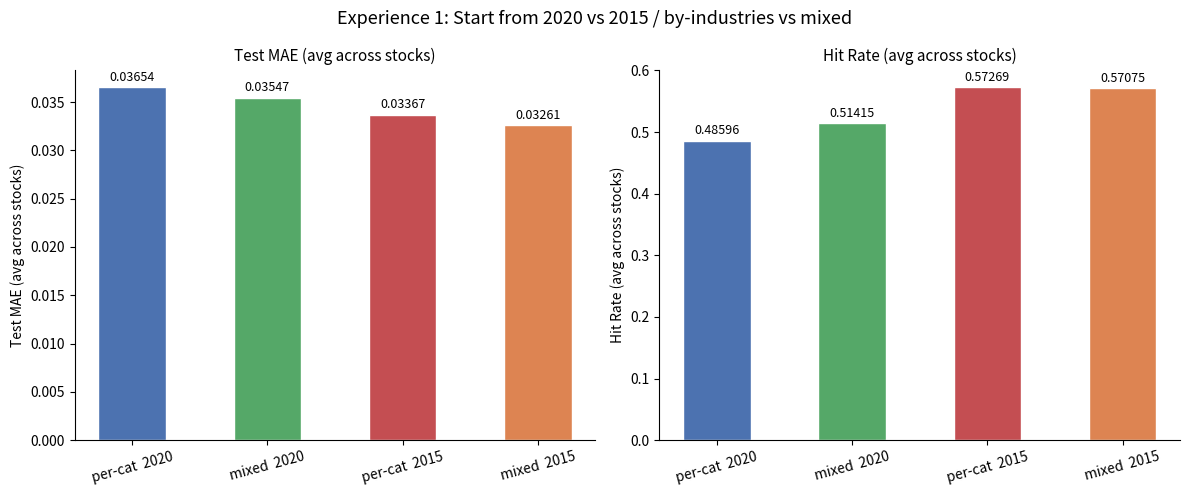

In [14]:
# 所有產業平均的 test MAE，比較 2020 vs 2015 x per-cat vs mixed
summary_exp1 = []
for label in ['2020', '2015']:
    # per-cat 平均
    cat_maes = [r['test']['mae'] for r in exp1_per_cat.get(label, {}).values()]
    cat_hits = [r['test']['hit_rate'] for r in exp1_per_cat.get(label, {}).values()]
    if cat_maes:
        summary_exp1.append({
            'label':    f'per-cat  {label}',
            'test_mae': np.mean(cat_maes),
            'hit_rate': np.mean(cat_hits),
        })
    # mixed
    if label in exp1_mixed:
        res = exp1_mixed[label]
        summary_exp1.append({
            'label':    f'mixed  {label}',
            'test_mae': res['test']['mae'],
            'hit_rate': res['test']['hit_rate'],
        })

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
df_s = pd.DataFrame(summary_exp1)
colors = ['#4C72B0', '#55A868', '#C44E52', '#DD8452']

for ax, metric, ylabel in zip(axes,
                               ['test_mae', 'hit_rate'],
                               ['Test MAE (avg across stocks)', 'Hit Rate (avg across stocks)']):
    bars = ax.bar(df_s['label'], df_s[metric].astype(float),
                  color=colors[:len(df_s)], width=0.5, edgecolor='white')
    for bar, val in zip(bars, df_s[metric].astype(float)):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + df_s[metric].astype(float).max() * 0.01,
                f'{val:.5f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(ylabel, fontsize=11)
    ax.set_ylabel(ylabel)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='x', rotation=15)

fig.suptitle('Experience 1: Start from 2020 vs 2015 / by-industries vs mixed', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### §2.4  折線圖（Ground Truth vs. Forecast）

**Grid 版**：同一產業所有股票並排  
**Per-stock 版**：每支股票獨立大圖

Per-category 較佳資料集: 2015
Mixed 較佳資料集:        2015


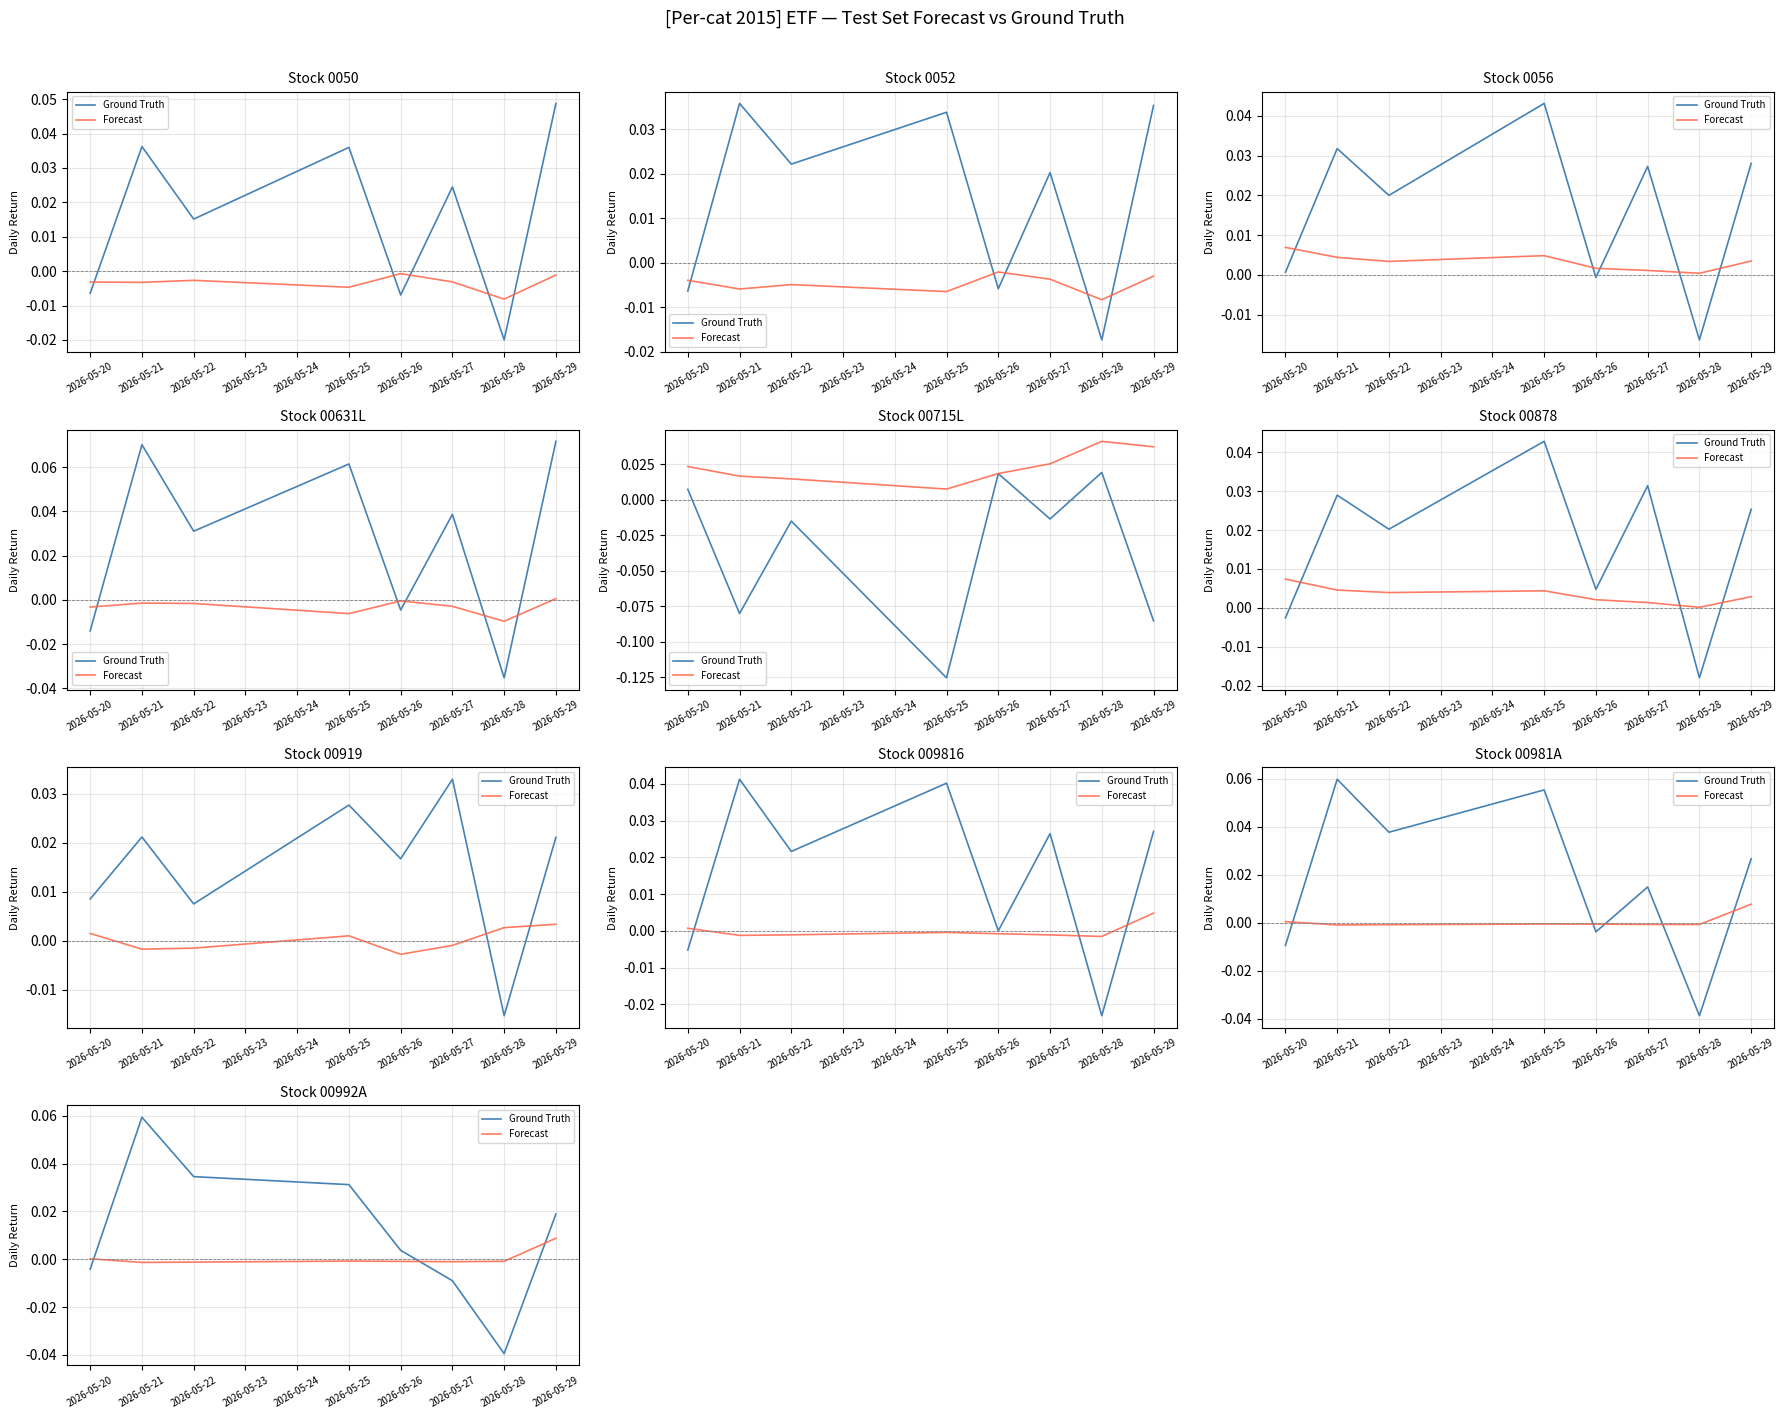

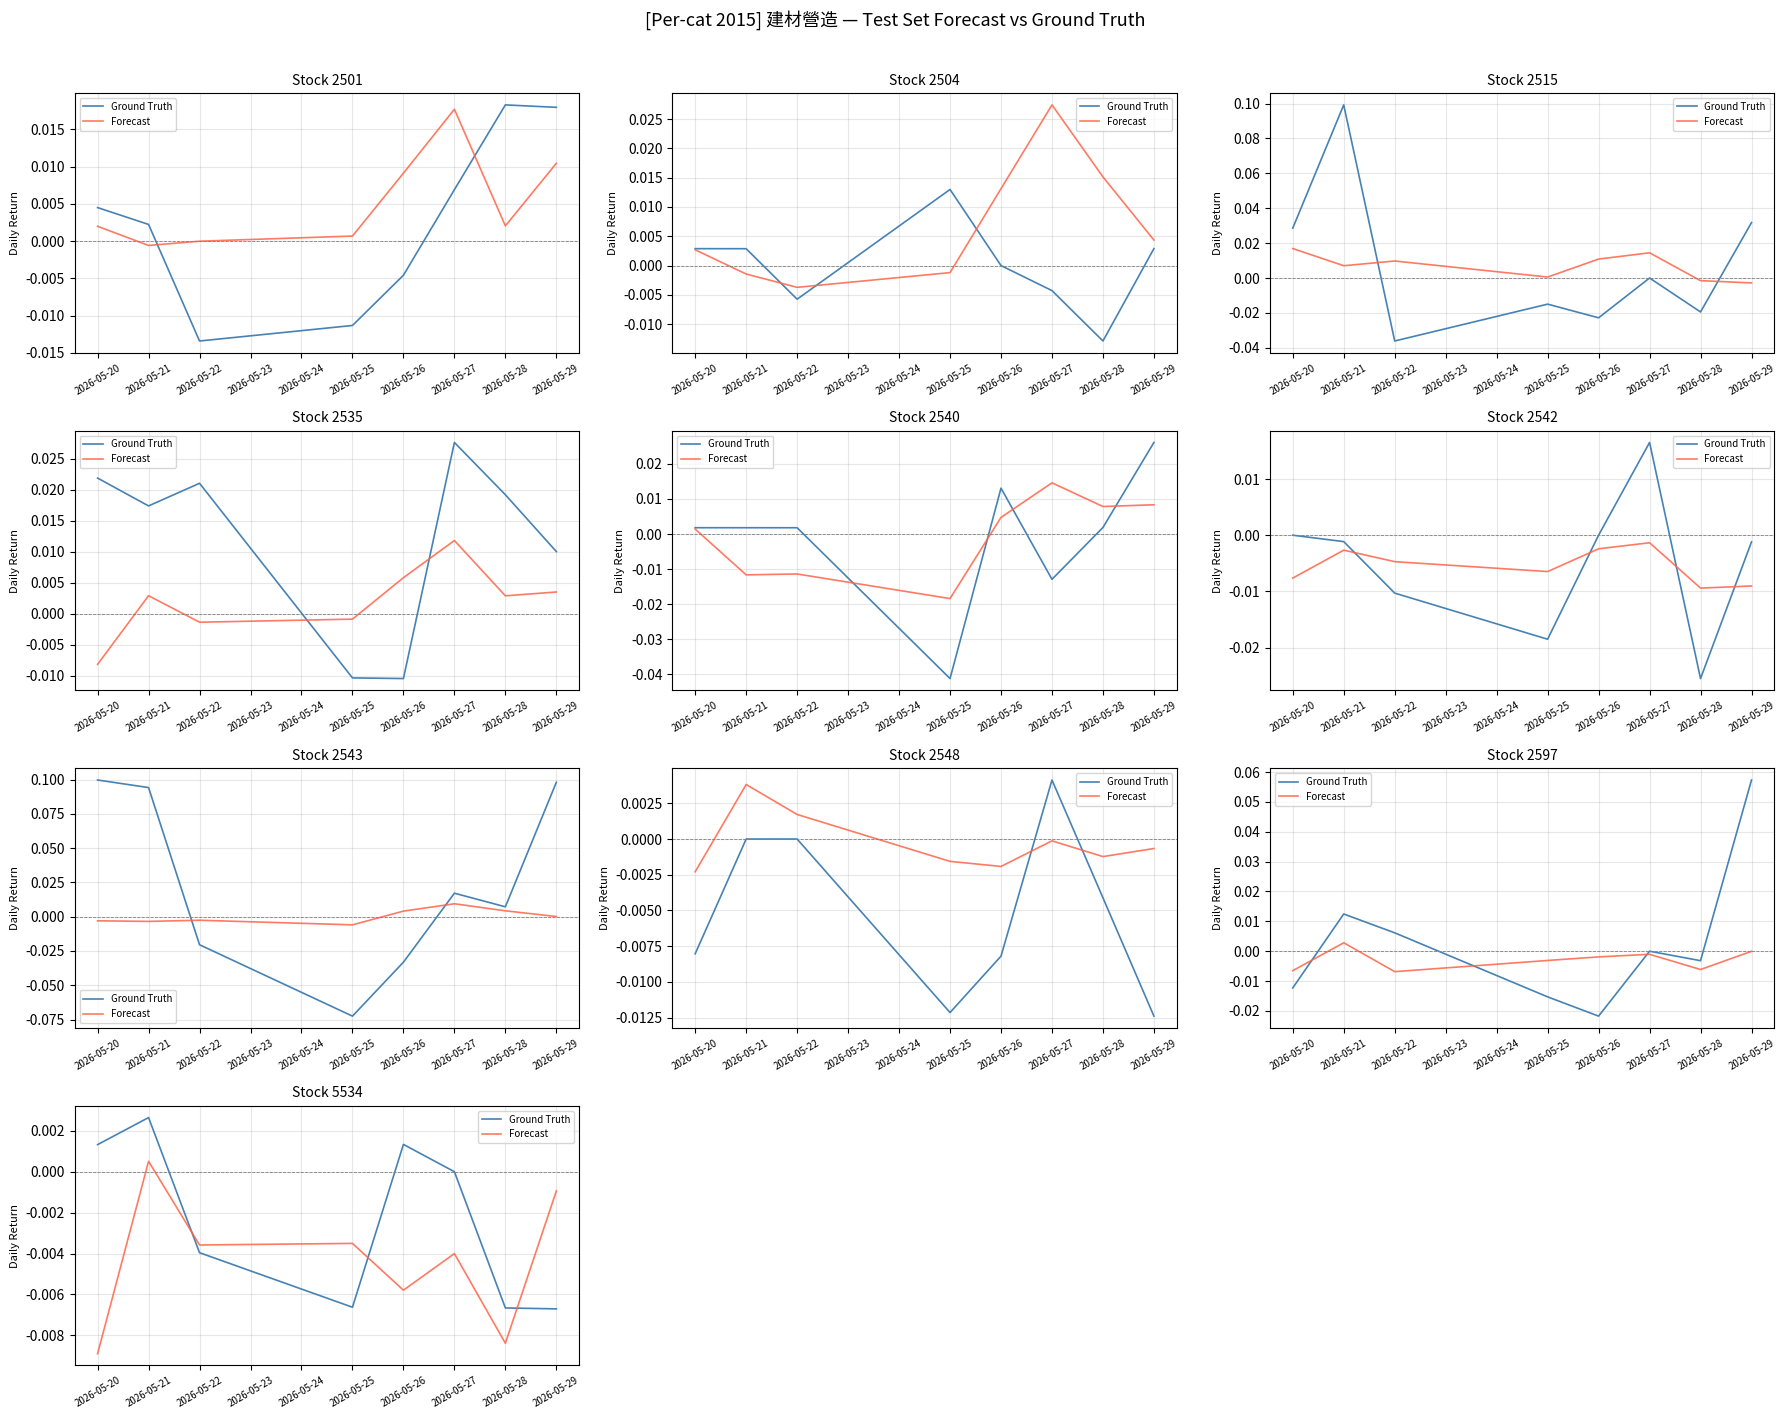

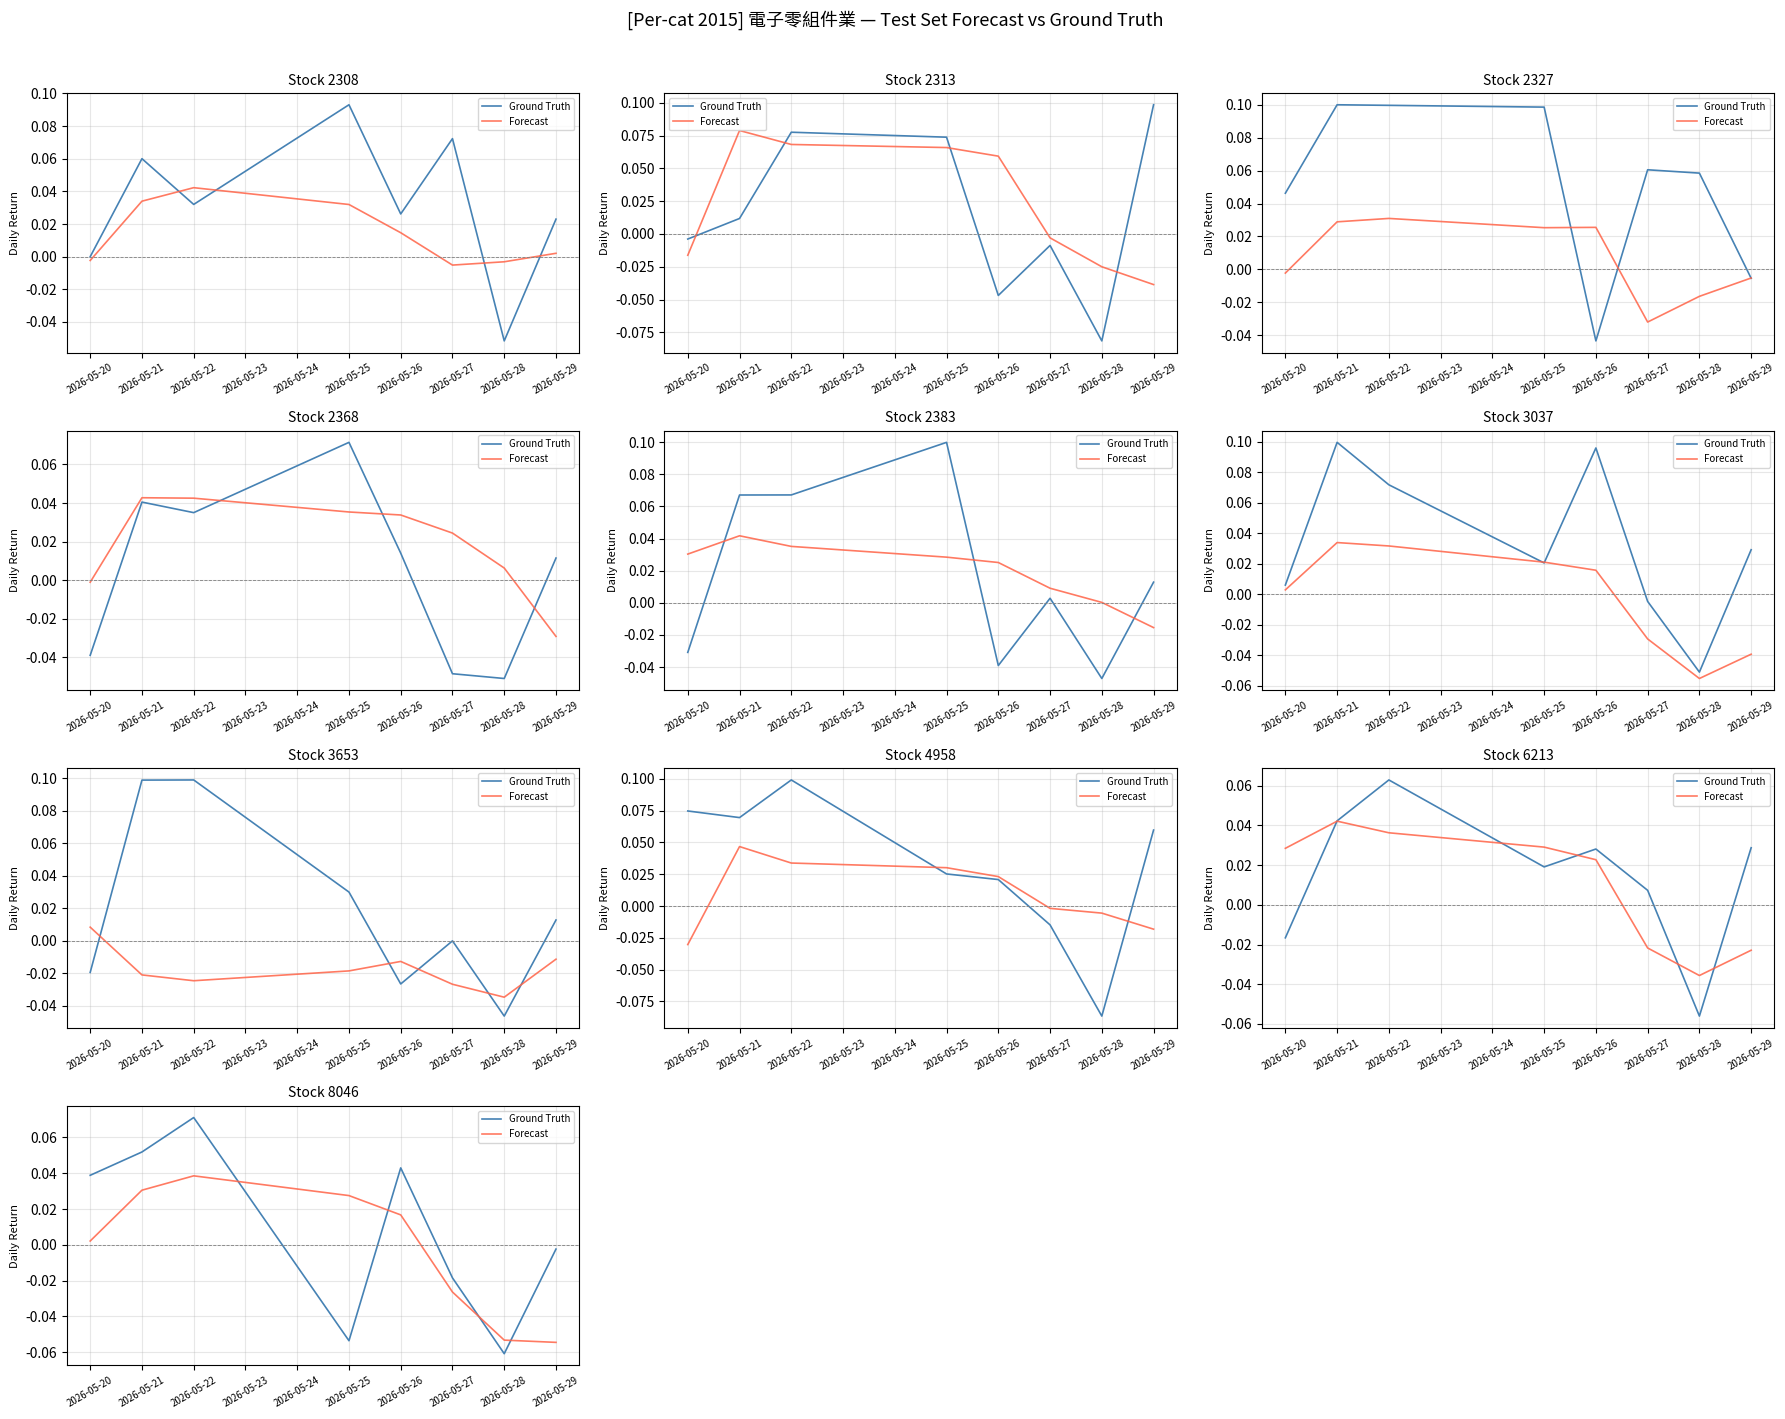

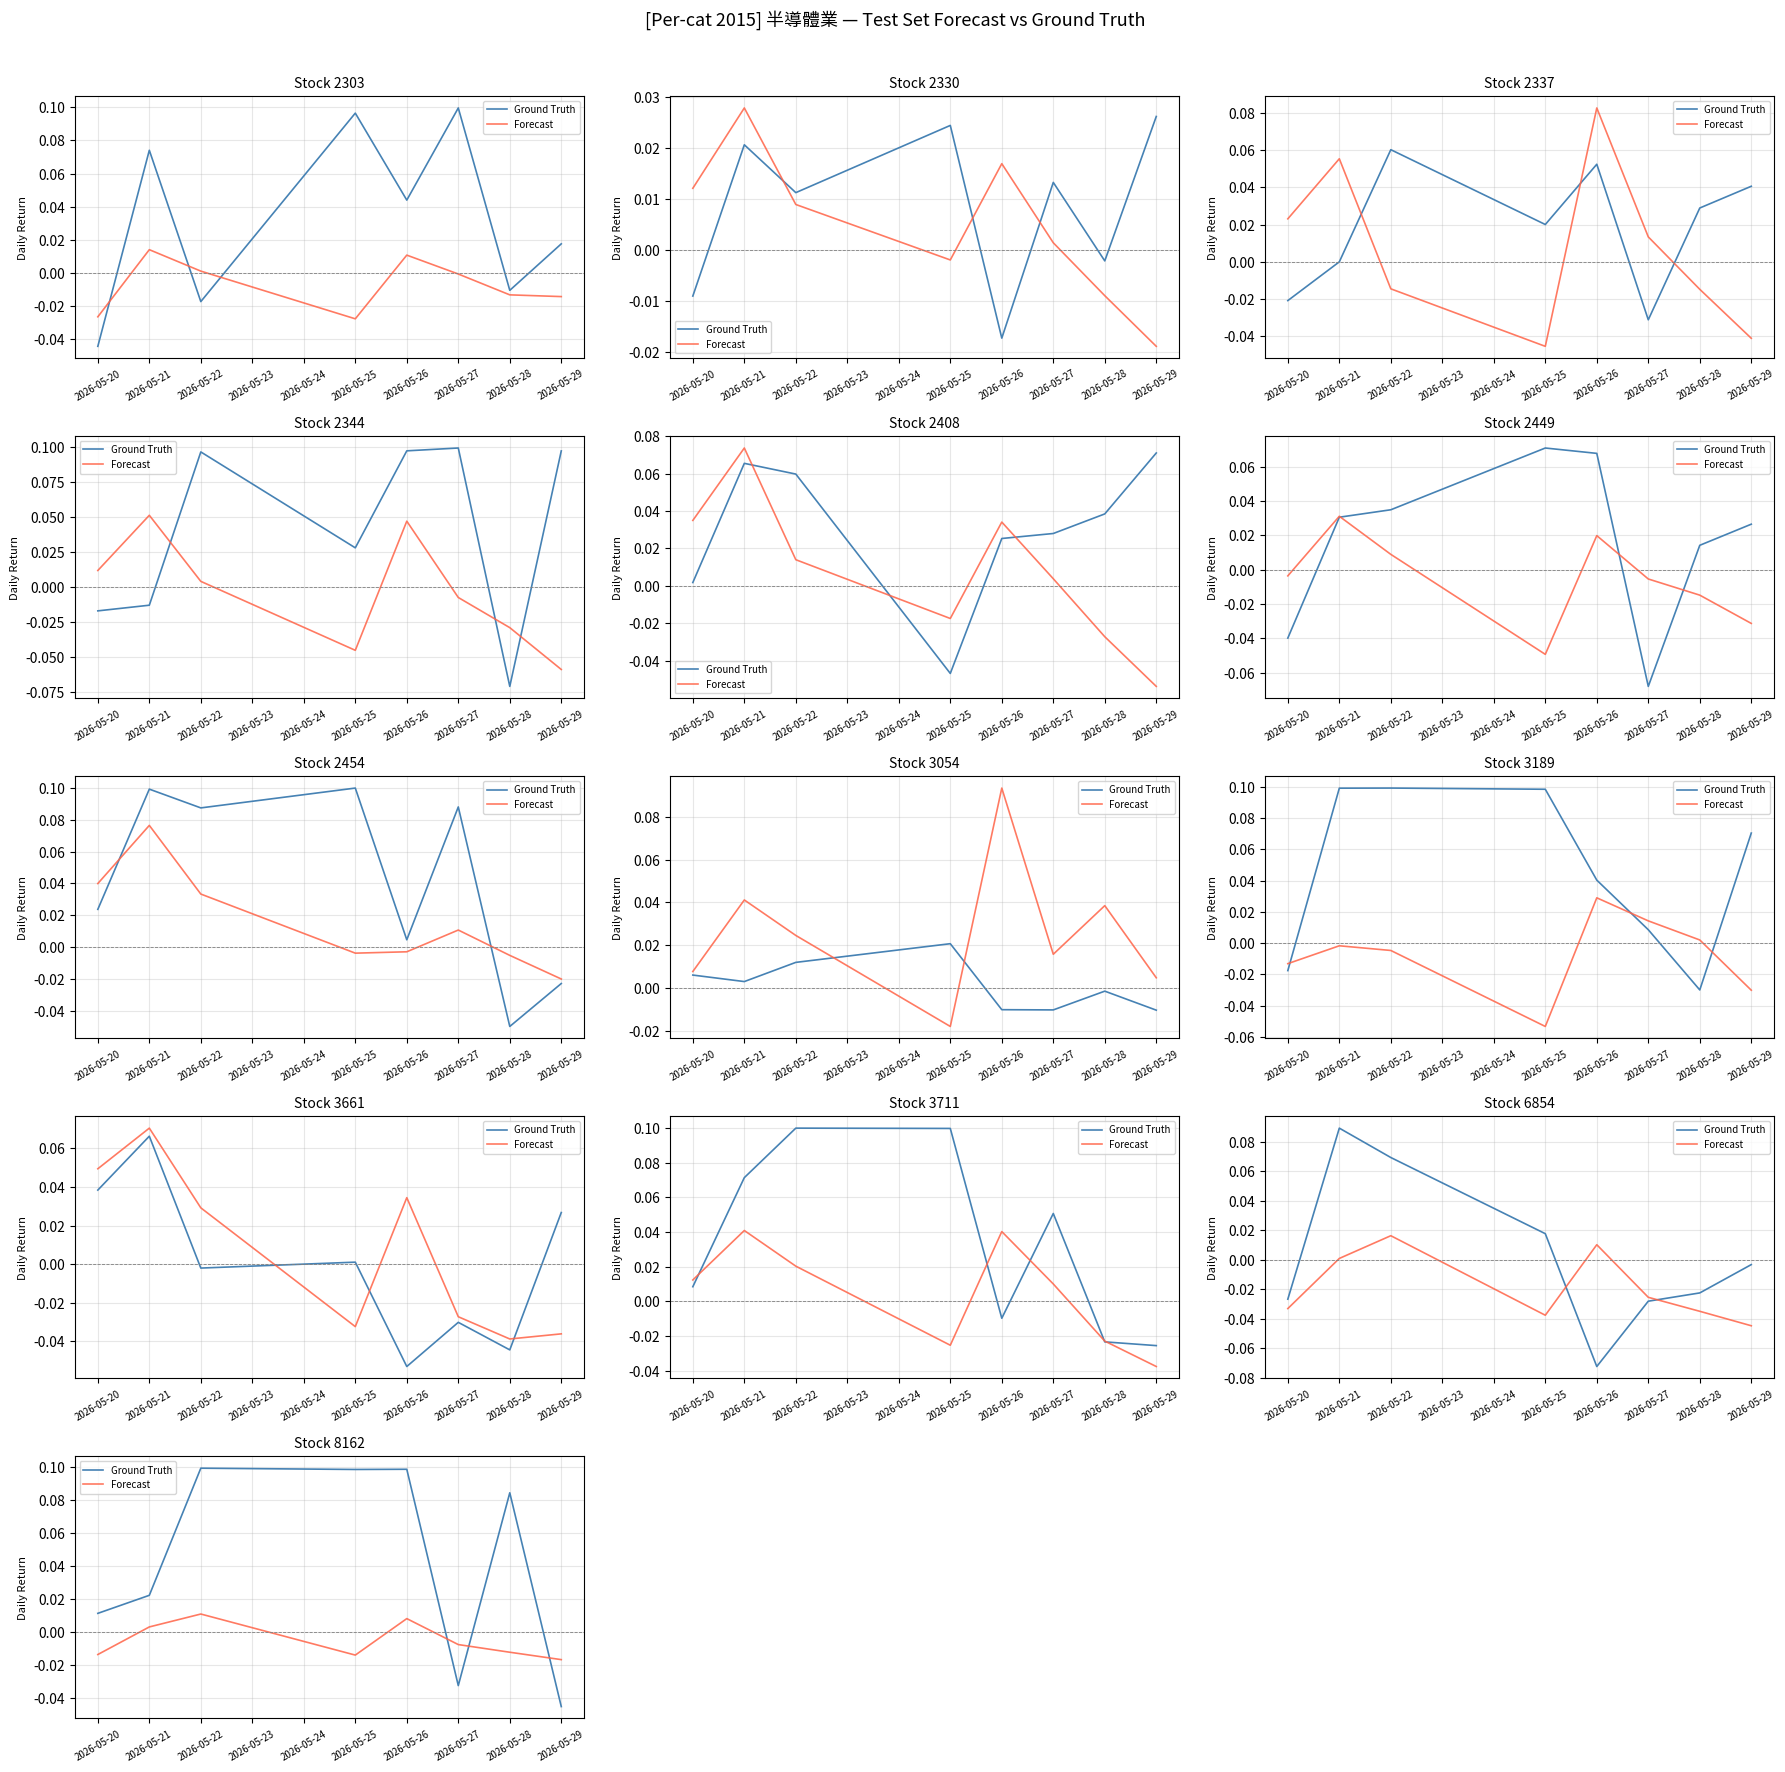

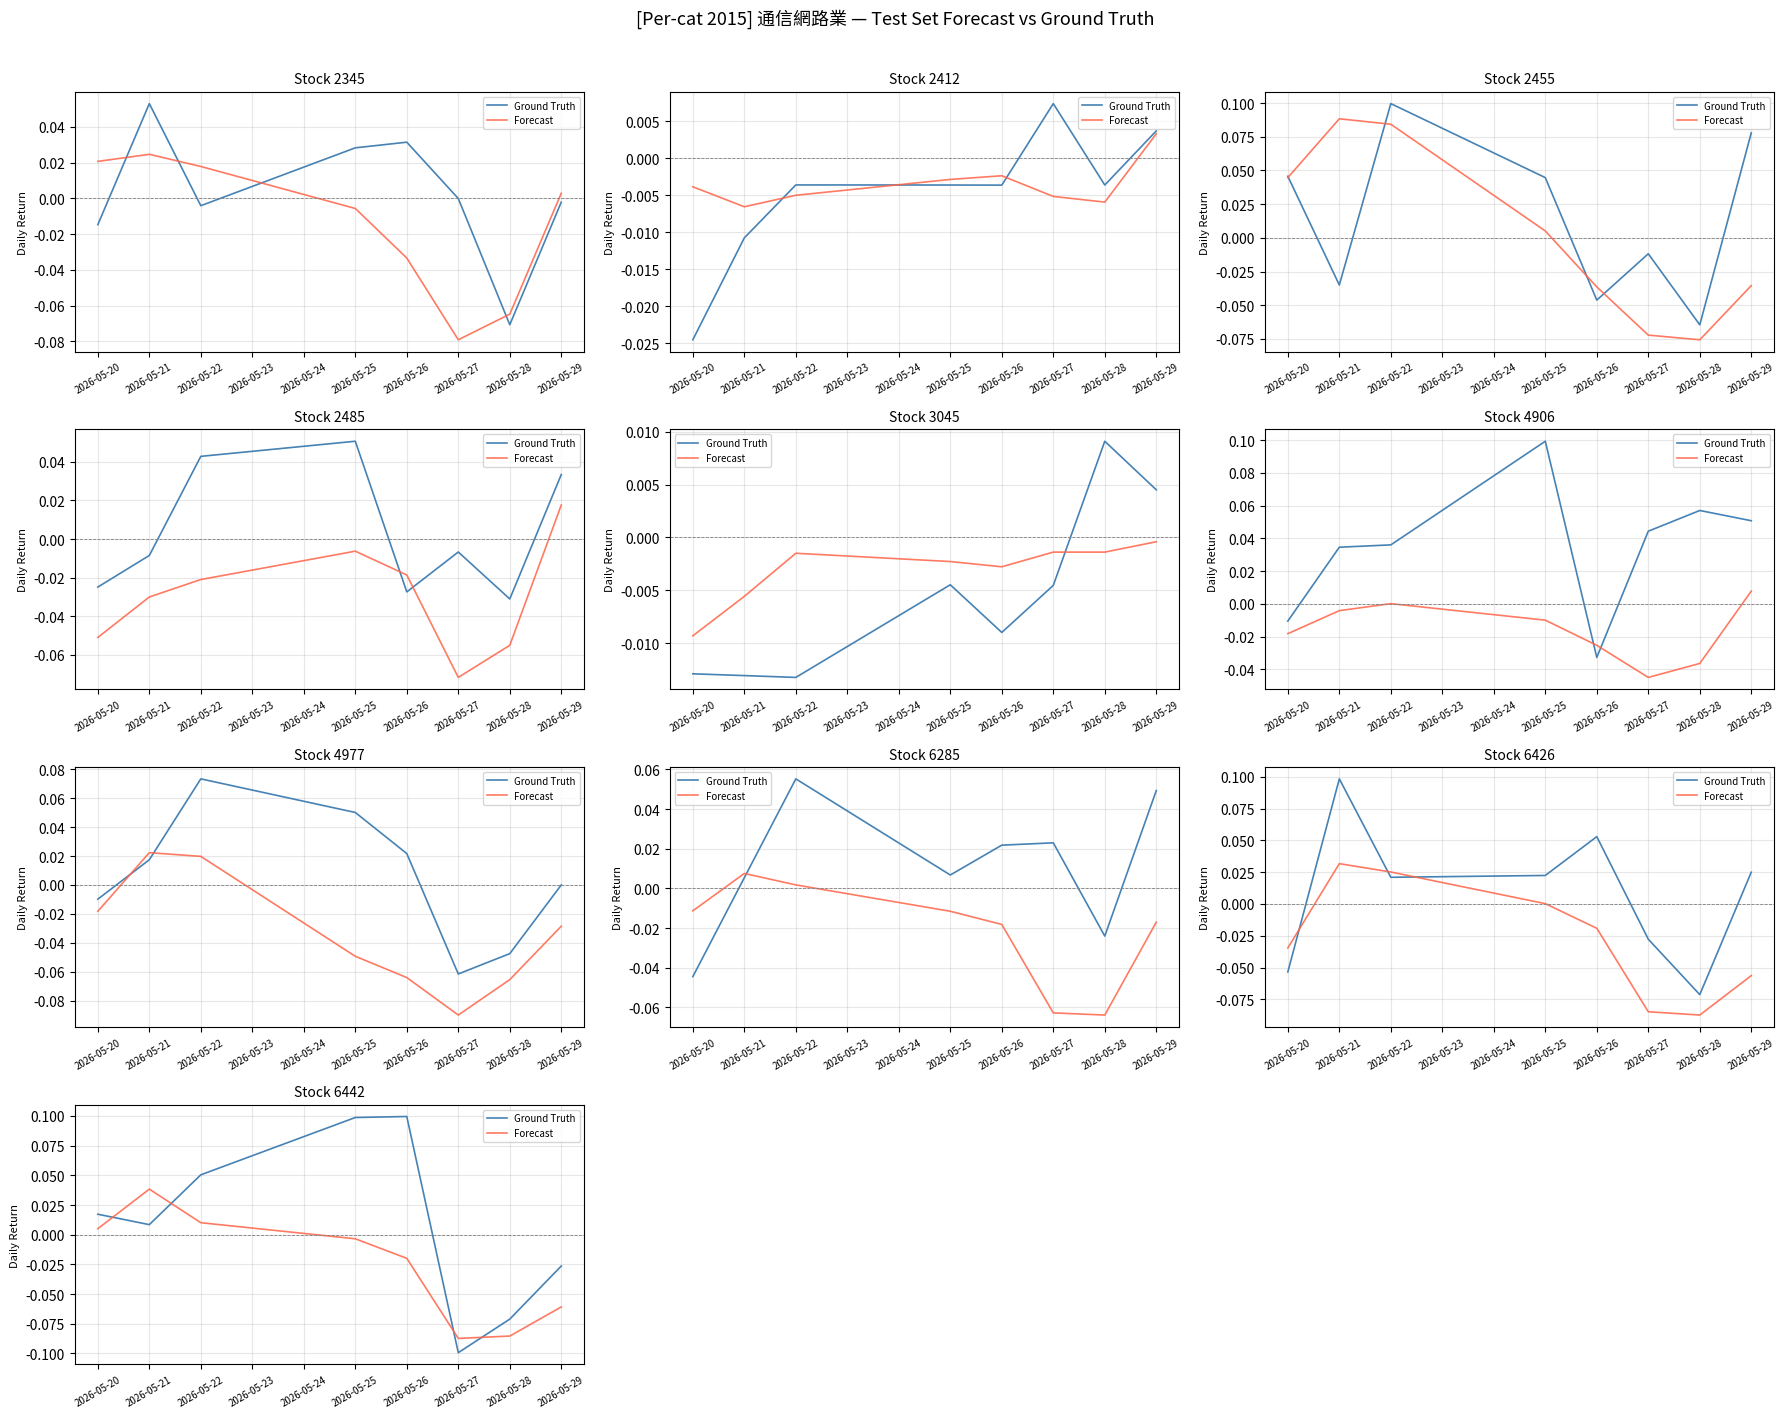

In [15]:
# 選定「最佳資料集版本」來畫折線圖
# 判斷標準：per-category 所有產業 test MAE 均值較低的 label
best_label_per_cat = min(
    ['2020', '2015'],
    key=lambda lb: np.mean([r['test']['mae'] for r in exp1_per_cat.get(lb, {}).values()] or [np.inf])
)
best_label_mixed = min(
    ['2020', '2015'],
    key=lambda lb: exp1_mixed[lb]['test']['mae'] if lb in exp1_mixed else np.inf
)
print(f'Per-category 較佳資料集: {best_label_per_cat}')
print(f'Mixed 較佳資料集:        {best_label_mixed}')

# ── Per-category：各產業的 grid 折線圖 ──────────────────────────────────────
for cat, res in exp1_per_cat.get(best_label_per_cat, {}).items():
    plot_predictions_grid(
        res['true_ret'], res['pred_ret'], res['stock_codes'], res['test_dates'],
        title=f'[Per-cat {best_label_per_cat}] {cat} — Test Set Forecast vs Ground Truth'
    )

In [ ]:
# Per-stock 個別大圖（per-category 最佳版本）
for cat, res in exp1_per_cat.get(best_label_per_cat, {}).items():
    plot_predictions_per_stock(
        res['true_ret'], res['pred_ret'], res['stock_codes'], res['test_dates'],
        title_prefix=f'[Per-cat {best_label_per_cat}] {cat}'
    )

In [ ]:
# Mixed 最佳版本 grid 折線圖
if best_label_mixed in exp1_mixed:
    res = exp1_mixed[best_label_mixed]
    plot_predictions_grid(
        res['true_ret'], res['pred_ret'], res['stock_codes'], res['test_dates'],
        title=f'[Mixed {best_label_mixed}] ALL stocks — Test Set Forecast vs Ground Truth'
    )
    plot_predictions_per_stock(
        res['true_ret'], res['pred_ret'], res['stock_codes'], res['test_dates'],
        title_prefix=f'[Mixed {best_label_mixed}]'
    )

## §3  實驗二：LSTM 架構搜索

**目的**：在§2 選出的最佳資料集上，比較 4 種 LSTM 架構，找出最佳參數組合。  
**固定條件**：最佳資料集（由§2 per-cat 平均 test MAE 決定）、相同的 per-category 訓練模式、相同的 test window。  
**候選架構**：

| 名稱 | num_layers | hidden_size |
|------|-----------|-------------|
| 3L-64H (baseline) | 3 | 64 |
| 1L-32H | 1 | 32 |
| 1L-16H | 1 | 16 |
| 2L-32H | 2 | 32 |

**選擇指標**：所有產業 test MAE 均值最低、hit rate 均值最高。

In [ ]:
ARCH_CANDIDATES = [
    {'name': '3L-64H', 'num_layers': 3, 'hidden_size': 64},
    {'name': '1L-32H', 'num_layers': 1, 'hidden_size': 32},
    {'name': '1L-16H', 'num_layers': 1, 'hidden_size': 16},
    {'name': '2L-32H', 'num_layers': 2, 'hidden_size': 32},
]

# 使用§2 決定的最佳 label，重新讀取資料（per-category）
# 若§2 已經跑過 best_label_per_cat，直接重用那份資料 dict
# 先快取各產業的 data dict，避免重複讀 DB

exp2_data_cache = {}   # cat -> data dict
for cat in CATEGORIES:
    df_raw = get_stock_data_by_category(
        cat,
        TRAIN_START_2020 if best_label_per_cat == '2020' else TRAIN_START_2015,
        TEST_END
    )
    if df_raw.empty:
        continue
    data = build_features_fixed_split(
        df_raw,
        TRAIN_START_2020 if best_label_per_cat == '2020' else TRAIN_START_2015,
        TEST_START, TEST_END
    )
    if data is not None:
        exp2_data_cache[cat] = data

print(f'資料集版本: {best_label_per_cat}，成功快取 {len(exp2_data_cache)} 個產業')

# ── 對每個架構、每個產業訓練 ─────────────────────────────────────────────────
exp2_results = {}   # arch_name -> {cat -> result}

for arch in ARCH_CANDIDATES:
    arch_name = arch['name']
    print(f'\n=== 架構 {arch_name} ===')
    exp2_results[arch_name] = {}
    for cat, data in exp2_data_cache.items():
        print(f'  [{cat}] 訓練中...')
        res = train_one(data, hidden_size=arch['hidden_size'], num_layers=arch['num_layers'])
        exp2_results[arch_name][cat] = res
        print(f'    test MAE={res["test"]["mae"]:.5f}  hit={res["test"]["hit_rate"]:.3f}')

print('\n完成所有架構訓練。')

NameError: name 'best_label_per_cat' is not defined

### §3.1  Metrics Summary Table

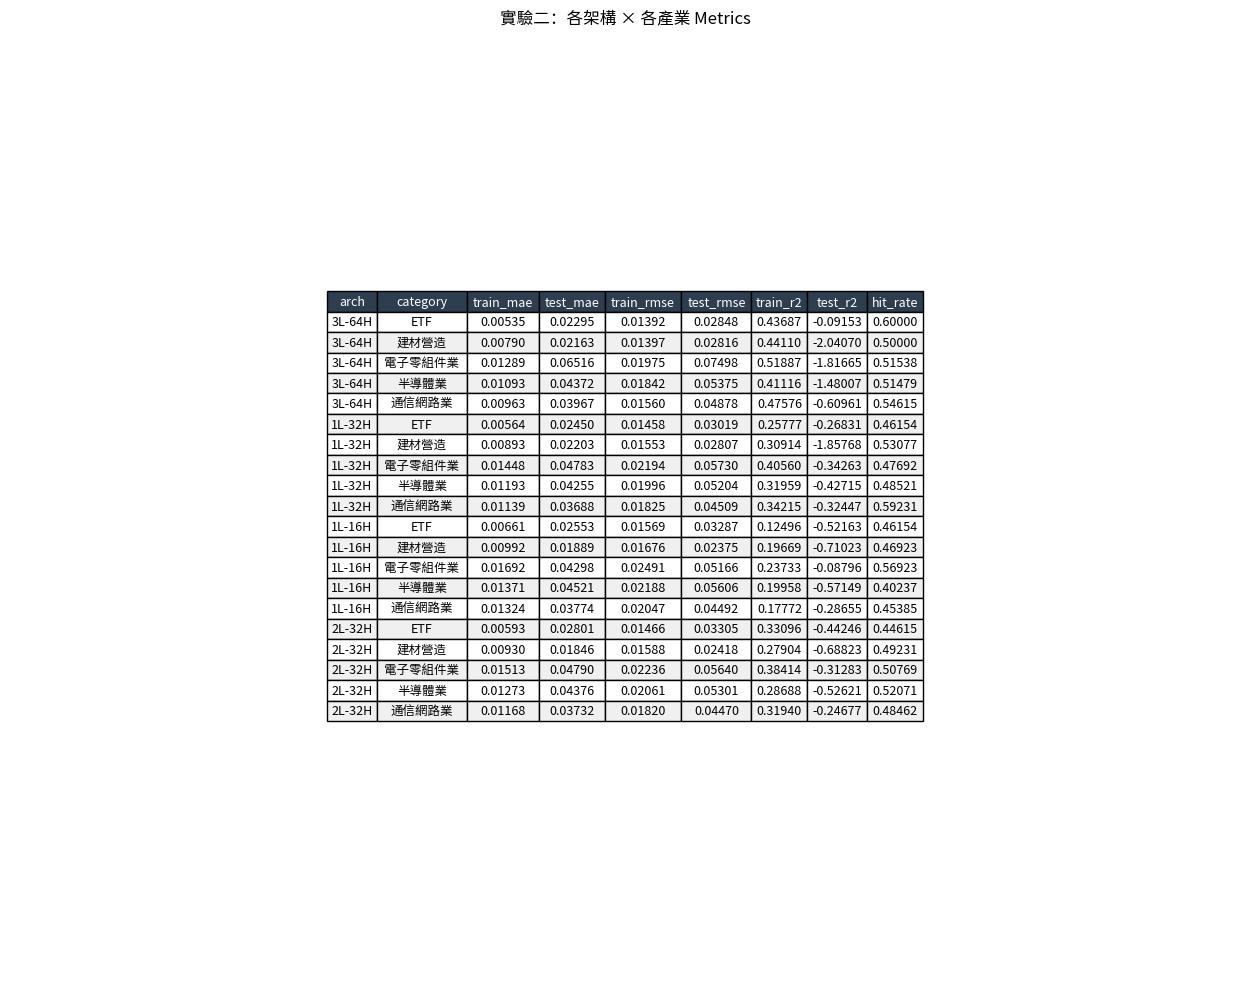


各架構 all-category 平均:
  arch  avg_test_mae  avg_hit_rate
1L-16H      0.034071      0.471243
1L-32H      0.034759      0.509349
2L-32H      0.035090      0.490296
3L-64H      0.038624      0.535266

=> 最佳架構: 1L-16H (num_layers=1, hidden=16)


In [ ]:
rows_exp2 = []
for arch in ARCH_CANDIDATES:
    arch_name = arch['name']
    cat_results = exp2_results.get(arch_name, {})
    if not cat_results:
        continue
    for cat, res in cat_results.items():
        rows_exp2.append({
            'arch':       arch_name,
            'category':   cat,
            'train_mae':  res['train']['mae'],
            'test_mae':   res['test']['mae'],
            'train_rmse': res['train']['rmse'],
            'test_rmse':  res['test']['rmse'],
            'train_r2':   res['train']['r2'],
            'test_r2':    res['test']['r2'],
            'hit_rate':   res['test']['hit_rate'],
        })

plot_metrics_table(rows_exp2, '實驗二：各架構 × 各產業 Metrics')

# 決定最佳架構（所有產業 test MAE 均值最低）
arch_summary = []
for arch in ARCH_CANDIDATES:
    arch_name = arch['name']
    cat_results = exp2_results.get(arch_name, {})
    if not cat_results:
        continue
    avg_mae = np.mean([r['test']['mae']   for r in cat_results.values()])
    avg_hit = np.mean([r['test']['hit_rate'] for r in cat_results.values()])
    arch_summary.append({'arch': arch_name, 'avg_test_mae': avg_mae, 'avg_hit_rate': avg_hit})

df_arch_summary = pd.DataFrame(arch_summary).sort_values('hit_rate')
print('\n各架構 all-category 平均:')
print(df_arch_summary.to_string(index=False))

best_arch_name   = df_arch_summary.iloc[0]['arch']
best_arch_config = next(a for a in ARCH_CANDIDATES if a['name'] == best_arch_name)
print(f'\n=> 最佳架構: {best_arch_name} (num_layers={best_arch_config["num_layers"]}, hidden={best_arch_config["hidden_size"]})')

### §3.2  Bar Chart 比較

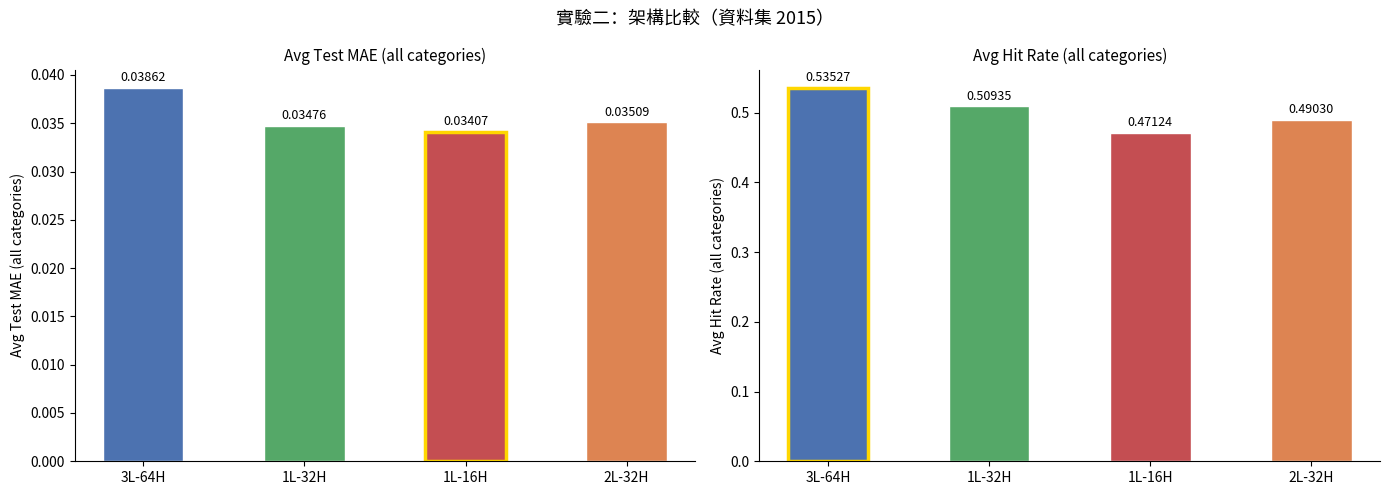

In [20]:
palette_arch = {'3L-64H': '#4C72B0', '1L-32H': '#55A868', '1L-16H': '#C44E52', '2L-32H': '#DD8452'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df_as = pd.DataFrame(arch_summary)

for ax, metric, ylabel in zip(axes,
                               ['avg_test_mae', 'avg_hit_rate'],
                               ['Avg Test MAE (all categories)', 'Avg Hit Rate (all categories)']):
    bars = ax.bar(
        df_as['arch'], df_as[metric].astype(float),
        color=[palette_arch.get(a, '#888888') for a in df_as['arch']],
        width=0.5, edgecolor='white'
    )
    for bar, val in zip(bars, df_as[metric].astype(float)):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + df_as[metric].astype(float).max() * 0.01,
                f'{val:.5f}', ha='center', va='bottom', fontsize=9)
    # 標示最佳架構
    best_idx = df_as[metric].astype(float).idxmin() if metric == 'avg_test_mae' \
               else df_as[metric].astype(float).idxmax()
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(2.5)
    ax.set_title(ylabel, fontsize=11)
    ax.set_ylabel(ylabel)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle(f'實驗二：架構比較（資料集 {best_label_per_cat}）', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## §4  實驗三：加入三大法人 + 融資融券特徵

**目的**：驗證市場動態特徵（法人動向、融資融券）能否提升預測能力。  
**設計**：以§3 選出的最佳架構，比較「無額外特徵（baseline）」vs「加入法人+融資融券」兩版本。  

**新增特徵**（皆 shift(1)，避免 lookahead bias）：

| 特徵 | 來源 | 說明 |
|------|------|------|
| `net_foreign` | `institutional` | 外資淨買超 (buy_Foreign_Investor - sell_Foreign_Investor) |
| `net_trust` | `institutional` | 投信淨買超 |
| `net_dealer_hedging` | `institutional` | 自營避險淨買超 |
| `net_dealer_self` | `institutional` | 自營自行淨買超 |
| `margin_balance` | `margin` | 融資餘額 (MarginPurchaseTodayBalance) |
| `margin_buy` | `margin` | 融資買進量 |
| `margin_sell` | `margin` | 融資賣出量 |
| `short_balance` | `margin` | 融券餘額 (ShortSaleTodayBalance) |
| `short_buy` | `margin` | 融券買進量 |
| `short_sell` | `margin` | 融券賣出量 |
| `offset_loan_short` | `margin` | 資券相抵 |

### §4.1  法人 + 融資融券特徵讀取函式

In [21]:
def fetch_institutional(stock_code: str, train_start: str, test_end: str) -> pd.DataFrame:
    """
    讀取三大法人資料，衍生淨買超欄位，shift(1) 避免 lookahead bias。
    回傳以 date 為 index 的 DataFrame，欄位：
      net_foreign, net_trust, net_dealer_hedging, net_dealer_self
    """
    try:
        df = pd.read_sql(
            f"SELECT date, buy_Foreign_Investor, sell_Foreign_Investor, "
            f"       buy_Investment_Trust, sell_Investment_Trust, "
            f"       buy_Dealer_Hedging, sell_Dealer_Hedging, "
            f"       buy_Dealer_self, sell_Dealer_self "
            f'FROM "institutional_{stock_code}" '
            f"WHERE date BETWEEN '{train_start}' AND '{test_end}' "
            f"ORDER BY date ASC",
            ENGINE
        )
    except Exception as e:
        logging.error(f"institutional_{stock_code}: {e}")
        return pd.DataFrame()

    if df.empty:
        return df

    df['date'] = pd.to_datetime(df['date']).dt.normalize()
    df = df.set_index('date')

    # 轉成 float，None -> NaN
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    df['net_foreign']         = df['buy_Foreign_Investor']  - df['sell_Foreign_Investor']
    df['net_trust']           = df['buy_Investment_Trust']  - df['sell_Investment_Trust']
    df['net_dealer_hedging']  = df['buy_Dealer_Hedging']    - df['sell_Dealer_Hedging']
    df['net_dealer_self']     = df['buy_Dealer_self']       - df['sell_Dealer_self']

    result = df[['net_foreign', 'net_trust', 'net_dealer_hedging', 'net_dealer_self']].copy()
    # shift(1)：用昨日法人資料預測今日，避免使用當日收盤後才揭露的資訊
    result = result.shift(1)
    return result


def fetch_margin(stock_code: str, train_start: str, test_end: str) -> pd.DataFrame:
    """
    讀取融資融券資料，shift(1) 避免 lookahead bias。
    回傳以 date 為 index 的 DataFrame，欄位：
      margin_balance, margin_buy, margin_sell,
      short_balance, short_buy, short_sell, offset_loan_short
    """
    try:
        df = pd.read_sql(
            f"SELECT date, "
            f"  \"MarginPurchaseTodayBalance\" AS margin_balance, "
            f"  \"MarginPurchaseBuy\"          AS margin_buy, "
            f"  \"MarginPurchaseSell\"         AS margin_sell, "
            f"  \"ShortSaleTodayBalance\"      AS short_balance, "
            f"  \"ShortSaleBuy\"               AS short_buy, "
            f"  \"ShortSaleSell\"              AS short_sell, "
            f"  \"OffsetLoanAndShort\"         AS offset_loan_short "
            f"FROM margin_{stock_code} "
            f"WHERE date BETWEEN '{train_start}' AND '{test_end}' "
            f"ORDER BY date ASC",
            ENGINE
        )
    except Exception as e:
        logging.error(f"margin_{stock_code}: {e}")
        return pd.DataFrame()

    if df.empty:
        return df

    df['date'] = pd.to_datetime(df['date']).dt.normalize()
    df = df.set_index('date')
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # shift(1)：融資融券餘額在當日收盤後公告，故 shift 一天
    return df.shift(1)


def build_features_with_market_signals(
    df: pd.DataFrame,
    train_start: str,
    test_start: str,
    test_end: str,
) -> dict | None:
    """
    在 build_features_fixed_split 的基礎上，額外接入三大法人與融資融券特徵。
    每支股票的法人/融資融券欄位以 wide format 拼入 feature_df（欄名加 stock_code 後綴）。
    """
    from model.feature_engineering import EXTRA_COLS

    df = df.copy()
    df['date'] = pd.to_datetime(df['date']).dt.normalize()
    stock_codes = sorted(df['stock_code_id'].unique())

    # ── 基礎 OHLCV 特徵（同 build_features_fixed_split）────────────────────
    close_wide = (
        df.groupby(['date', 'stock_code_id'], as_index=False)['close']
        .mean()
        .pivot_table(index='date', columns='stock_code_id', values='close', aggfunc='mean')
        .sort_index().ffill().bfill()
    )
    close_wide.columns = [f"close_{c}" for c in close_wide.columns]

    extra_list = []
    for col in EXTRA_COLS:
        if col not in df.columns:
            continue
        w = (
            df.groupby(['date', 'stock_code_id'], as_index=False)[col]
            .mean()
            .pivot_table(index='date', columns='stock_code_id', values=col, aggfunc='mean')
            .sort_index().ffill().bfill()
        )
        w.columns = [f"{col}_{c}" for c in w.columns]
        extra_list.append(w)

    ret_wide = close_wide.pct_change().replace([np.inf, -np.inf], np.nan).fillna(0.0)
    ret_wide.columns = [f"ret_{c.split('_')[1]}" for c in close_wide.columns]

    rel_close = close_wide.sub(close_wide.mean(axis=1), axis=0)
    rel_close.columns = [f"rel_{c}" for c in close_wide.columns]

    # ── 法人 + 融資融券 wide 特徵 ────────────────────────────────────────────
    inst_frames, marg_frames = [], []
    for code in stock_codes:
        df_inst = fetch_institutional(str(code), train_start, test_end)
        if not df_inst.empty:
            df_inst.columns = [f"{col}_{code}" for col in df_inst.columns]
            inst_frames.append(df_inst)

        df_marg = fetch_margin(str(code), train_start, test_end)
        if not df_marg.empty:
            df_marg.columns = [f"{col}_{code}" for col in df_marg.columns]
            marg_frames.append(df_marg)

    feature_df = pd.concat(
        [close_wide] + extra_list + [
            ret_wide,
            close_wide.mean(axis=1).to_frame('market_mean_close'),
            ret_wide.mean(axis=1).to_frame('market_mean_ret'),
            rel_close,
        ] + inst_frames + marg_frames,
        axis=1,
    )

    # ffill 填補法人/融資融券可能的缺值（假日或初始 NaN 因 shift 產生）
    feature_df = feature_df.ffill().bfill().dropna()
    feature_df = feature_df[feature_df.index <= pd.Timestamp(test_end)]

    target_cols  = ret_wide.columns.tolist()
    feature_cols = feature_df.columns.tolist()

    df_train = feature_df[(feature_df.index >= pd.Timestamp(train_start)) &
                          (feature_df.index <  pd.Timestamp(test_start))]
    df_test  = feature_df[(feature_df.index >= pd.Timestamp(test_start)) &
                          (feature_df.index <= pd.Timestamp(test_end))]

    if len(df_train) < SEQ_LEN + 1 or len(df_test) < 1:
        return None

    x_scaler = StandardScaler()
    y_scaler = StandardScaler()
    X_tr = x_scaler.fit_transform(df_train[feature_cols].values)
    X_te = x_scaler.transform(df_test[feature_cols].values)
    y_tr = y_scaler.fit_transform(df_train[target_cols].values)
    y_te = y_scaler.transform(df_test[target_cols].values)

    X_train_seq, y_train_seq = create_sequences(X_tr, y_tr, SEQ_LEN)
    X_test_seq,  y_test_seq  = create_sequences(X_te, y_te, SEQ_LEN)

    if len(X_test_seq) == 0:
        return None

    print(f'  [+signal] feature 數: {len(feature_cols)} '
          f'(baseline 為 {len([c for c in feature_cols if not any(c.startswith(p) for p in ["net_","margin_","short_","offset_"])])})')

    return dict(
        X_train=X_train_seq, y_train=y_train_seq,
        X_test=X_test_seq,   y_test=y_test_seq,
        x_scaler=x_scaler,   y_scaler=y_scaler,
        feature_cols=feature_cols, target_cols=target_cols,
        df_train=df_train, df_test=df_test,
        close_wide=close_wide,
        stock_codes=[c.split('_')[1] for c in target_cols],
    )

### §4.2  訓練（baseline vs +signals）

In [22]:
# 最佳資料集起始日 & 最佳架構參數
exp3_train_start = TRAIN_START_2020 if best_label_per_cat == '2020' else TRAIN_START_2015
exp3_hl  = best_arch_config['hidden_size']
exp3_nl  = best_arch_config['num_layers']
print(f'實驗三設定: train_start={exp3_train_start}, arch={best_arch_name} '
      f'(hidden={exp3_hl}, layers={exp3_nl})')

exp3_baseline = {}   # cat -> result (無額外特徵，直接用 exp2 跑過的結果)
exp3_signals  = {}   # cat -> result (加入法人+融資融券)

for cat in CATEGORIES:
    # baseline：直接取 exp2 中最佳架構的結果（已訓練過，不重跑）
    if cat in exp2_results.get(best_arch_name, {}):
        exp3_baseline[cat] = exp2_results[best_arch_name][cat]

    # +signals：重新讀取資料並訓練
    print(f'\n[{cat}] 讀取含法人/融資融券資料...')
    df_raw = get_stock_data_by_category(cat, exp3_train_start, TEST_END)
    if df_raw.empty:
        print('  => 無資料，略過')
        continue

    data_sig = build_features_with_market_signals(df_raw, exp3_train_start, TEST_START, TEST_END)
    if data_sig is None:
        print('  => 資料不足，略過')
        continue

    print(f'  訓練中 (arch={best_arch_name})...')
    res = train_one(data_sig, hidden_size=exp3_hl, num_layers=exp3_nl)
    exp3_signals[cat] = res
    print(f'  => test MAE={res["test"]["mae"]:.5f}  hit={res["test"]["hit_rate"]:.3f}')

print('\n完成實驗三訓練。')

實驗三設定: train_start=2015-01-01, arch=1L-16H (hidden=16, layers=1)

[ETF] 讀取含法人/融資融券資料...


2026-06-23 17:03:07,347 - ERROR - institutional_0050: (psycopg.errors.UndefinedColumn) column "buy_foreign_investor" does not exist
LINE 1: SELECT date, buy_Foreign_Investor, sell_Foreign_Investor,   ...
                     ^
HINT:  Perhaps you meant to reference the column "institutional_0050.buy_Foreign_Investor".
[SQL: SELECT date, buy_Foreign_Investor, sell_Foreign_Investor,        buy_Investment_Trust, sell_Investment_Trust,        buy_Dealer_Hedging, sell_Dealer_Hedging,        buy_Dealer_self, sell_Dealer_self FROM "institutional_0050" WHERE date BETWEEN '2015-01-01' AND '2026-05-30' ORDER BY date ASC]
(Background on this error at: https://sqlalche.me/e/20/f405)
2026-06-23 17:03:07,385 - ERROR - institutional_0052: (psycopg.errors.UndefinedColumn) column "buy_foreign_investor" does not exist
LINE 1: SELECT date, buy_Foreign_Investor, sell_Foreign_Investor,   ...
                     ^
HINT:  Perhaps you meant to reference the column "institutional_0052.buy_Foreign_Investor".
[S

  [+signal] feature 數: 134 (baseline 為 92)
  訓練中 (arch=1L-16H)...
  => test MAE=0.02273  hit=0.569

[建材營造] 讀取含法人/融資融券資料...


2026-06-23 17:03:49,167 - ERROR - institutional_2501: (psycopg.errors.UndefinedColumn) column "buy_foreign_investor" does not exist
LINE 1: SELECT date, buy_Foreign_Investor, sell_Foreign_Investor,   ...
                     ^
HINT:  Perhaps you meant to reference the column "institutional_2501.buy_Foreign_Investor".
[SQL: SELECT date, buy_Foreign_Investor, sell_Foreign_Investor,        buy_Investment_Trust, sell_Investment_Trust,        buy_Dealer_Hedging, sell_Dealer_Hedging,        buy_Dealer_self, sell_Dealer_self FROM "institutional_2501" WHERE date BETWEEN '2015-01-01' AND '2026-05-30' ORDER BY date ASC]
(Background on this error at: https://sqlalche.me/e/20/f405)
2026-06-23 17:03:49,196 - ERROR - institutional_2504: (psycopg.errors.UndefinedColumn) column "buy_foreign_investor" does not exist
LINE 1: SELECT date, buy_Foreign_Investor, sell_Foreign_Investor,   ...
                     ^
HINT:  Perhaps you meant to reference the column "institutional_2504.buy_Foreign_Investor".
[S

  [+signal] feature 數: 162 (baseline 為 92)
  訓練中 (arch=1L-16H)...
  => test MAE=0.01833  hit=0.500

[電子零組件業] 讀取含法人/融資融券資料...


...

  [+signal] feature 數: 162 (baseline 為 92)
  訓練中 (arch=1L-16H)...
  => test MAE=0.04721  hit=0.500

[半導體業] 讀取含法人/融資融券資料...


2026-06-23 17:04:58,609 - ERROR - institutional_2303: (psycopg.errors.UndefinedColumn) column "buy_foreign_investor" does not exist
LINE 1: SELECT date, buy_Foreign_Investor, sell_Foreign_Investor,   ...
                     ^
HINT:  Perhaps you meant to reference the column "institutional_2303.buy_Foreign_Investor".
[SQL: SELECT date, buy_Foreign_Investor, sell_Foreign_Investor,        buy_Investment_Trust, sell_Investment_Trust,        buy_Dealer_Hedging, sell_Dealer_Hedging,        buy_Dealer_self, sell_Dealer_self FROM "institutional_2303" WHERE date BETWEEN '2015-01-01' AND '2026-05-30' ORDER BY date ASC]
(Background on this error at: https://sqlalche.me/e/20/f405)
2026-06-23 17:04:58,637 - ERROR - institutional_2330: (psycopg.errors.UndefinedColumn) column "buy_foreign_investor" does not exist
LINE 1: SELECT date, buy_Foreign_Investor, sell_Foreign_Investor,   ...
                     ^
HINT:  Perhaps you meant to reference the column "institutional_2330.buy_Foreign_Investor".
[S

  [+signal] feature 數: 210 (baseline 為 119)
  訓練中 (arch=1L-16H)...
  => test MAE=0.04336  hit=0.456

[通信網路業] 讀取含法人/融資融券資料...


2026-06-23 17:05:33,290 - ERROR - institutional_2345: (psycopg.errors.UndefinedColumn) column "buy_foreign_investor" does not exist
LINE 1: SELECT date, buy_Foreign_Investor, sell_Foreign_Investor,   ...
                     ^
HINT:  Perhaps you meant to reference the column "institutional_2345.buy_Foreign_Investor".
[SQL: SELECT date, buy_Foreign_Investor, sell_Foreign_Investor,        buy_Investment_Trust, sell_Investment_Trust,        buy_Dealer_Hedging, sell_Dealer_Hedging,        buy_Dealer_self, sell_Dealer_self FROM "institutional_2345" WHERE date BETWEEN '2015-01-01' AND '2026-05-30' ORDER BY date ASC]
(Background on this error at: https://sqlalche.me/e/20/f405)
2026-06-23 17:05:33,313 - ERROR - institutional_2412: (psycopg.errors.UndefinedColumn) column "buy_foreign_investor" does not exist
LINE 1: SELECT date, buy_Foreign_Investor, sell_Foreign_Investor,   ...
                     ^
HINT:  Perhaps you meant to reference the column "institutional_2412.buy_Foreign_Investor".
[S

  [+signal] feature 數: 162 (baseline 為 92)
  訓練中 (arch=1L-16H)...
  => test MAE=0.03546  hit=0.492

完成實驗三訓練。


### §4.3  Metrics 對比 Table

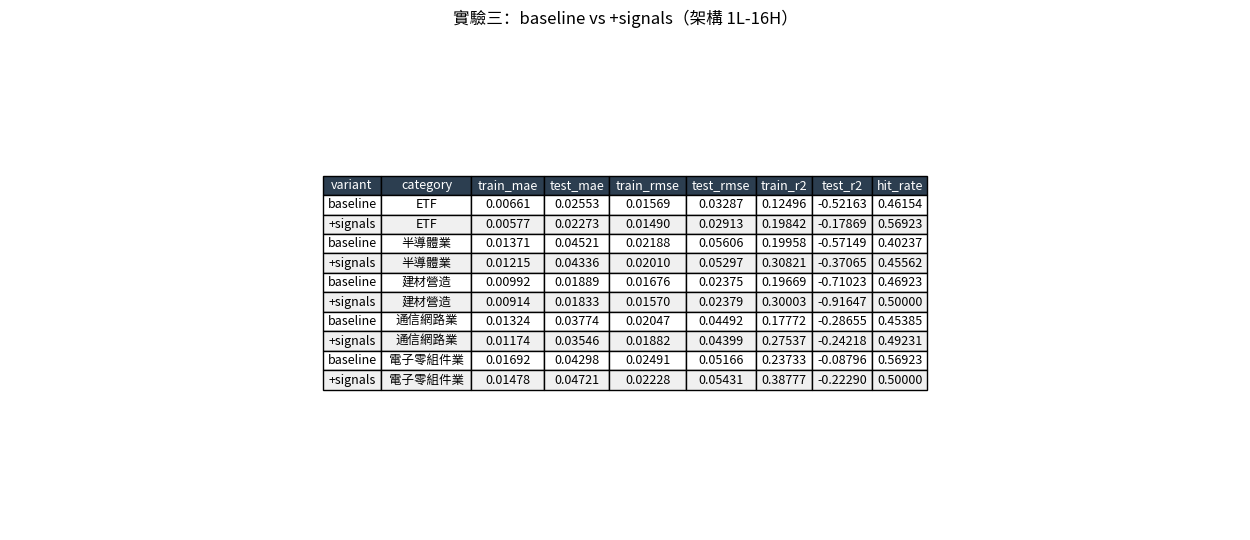

baseline      avg test MAE=0.03407  avg hit rate=0.4712
+signals      avg test MAE=0.03342  avg hit rate=0.5034


In [23]:
rows_exp3 = []
all_cats = sorted(set(list(exp3_baseline.keys()) + list(exp3_signals.keys())))

for cat in all_cats:
    for variant, store in [('baseline', exp3_baseline), ('+signals', exp3_signals)]:
        if cat not in store:
            continue
        res = store[cat]
        rows_exp3.append({
            'variant':    variant,
            'category':   cat,
            'train_mae':  res['train']['mae'],
            'test_mae':   res['test']['mae'],
            'train_rmse': res['train']['rmse'],
            'test_rmse':  res['test']['rmse'],
            'train_r2':   res['train']['r2'],
            'test_r2':    res['test']['r2'],
            'hit_rate':   res['test']['hit_rate'],
        })

plot_metrics_table(rows_exp3, f'實驗三：baseline vs +signals（架構 {best_arch_name}）')

# 跨產業平均比較
for variant, store in [('baseline', exp3_baseline), ('+signals', exp3_signals)]:
    maes = [r['test']['mae']      for r in store.values()]
    hits = [r['test']['hit_rate'] for r in store.values()]
    print(f'{variant:12s}  avg test MAE={np.mean(maes):.5f}  avg hit rate={np.mean(hits):.4f}')

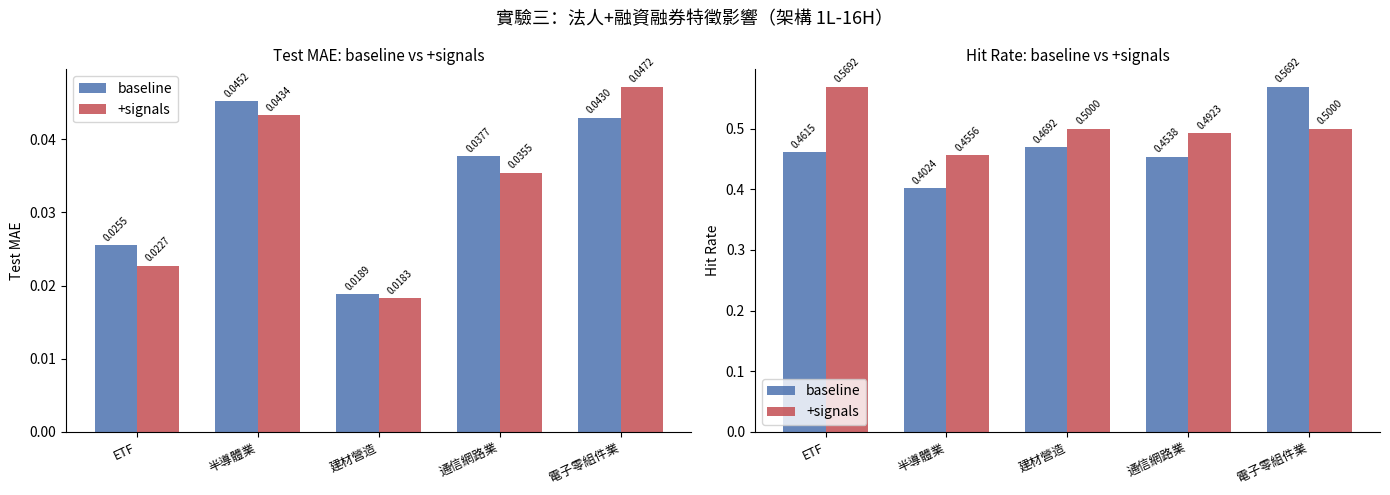

In [24]:
# ── Grouped bar chart：各產業 baseline vs +signals ──────────────────────────
df_e3 = pd.DataFrame(rows_exp3)
cats_ordered = sorted(df_e3['category'].unique())

fig, axes = plt.subplots(1, 2, figsize=(max(14, len(cats_ordered) * 2.2), 5))
x = np.arange(len(cats_ordered))
width = 0.35

for ax, metric, ylabel in zip(axes,
                               ['test_mae', 'hit_rate'],
                               ['Test MAE', 'Hit Rate']):
    vals_base = [df_e3[(df_e3['category'] == c) & (df_e3['variant'] == 'baseline')][metric].values[0]
                 if len(df_e3[(df_e3['category'] == c) & (df_e3['variant'] == 'baseline')]) else np.nan
                 for c in cats_ordered]
    vals_sig  = [df_e3[(df_e3['category'] == c) & (df_e3['variant'] == '+signals')][metric].values[0]
                 if len(df_e3[(df_e3['category'] == c) & (df_e3['variant'] == '+signals')]) else np.nan
                 for c in cats_ordered]

    b1 = ax.bar(x - width/2, vals_base, width, label='baseline', color='#4C72B0', alpha=0.85)
    b2 = ax.bar(x + width/2, vals_sig,  width, label='+signals', color='#C44E52', alpha=0.85)

    for bar, val in zip(list(b1) + list(b2), vals_base + vals_sig):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + max(v for v in vals_base + vals_sig if not np.isnan(v)) * 0.005,
                    f'{val:.4f}', ha='center', va='bottom', fontsize=7, rotation=45)

    ax.set_xticks(x)
    ax.set_xticklabels(cats_ordered, rotation=25, ha='right', fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel}: baseline vs +signals', fontsize=11)
    ax.legend()
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle(f'實驗三：法人+融資融券特徵影響（架構 {best_arch_name}）', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### §4.4  折線圖對比（baseline vs +signals，per stock）

兩條預測曲線疊在同一張圖上，與 ground truth 一起顯示，直觀觀察加入市場信號後預測的差異。

In [ ]:
def plot_comparison_grid(res_base, res_sig, cat: str):
    """
    同一產業，每個 stock 一個子圖，疊加 ground truth / baseline / +signals 三條線。
    """
    stock_codes = res_base['stock_codes']
    true_ret    = res_base['true_ret']
    pred_base   = res_base['pred_ret']
    pred_sig    = res_sig['pred_ret'] if res_sig is not None else None
    test_dates  = pd.to_datetime(res_base['test_dates'])

    n     = len(stock_codes)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 3.5 * nrows), sharex=False)
    axes_flat = np.array(axes).flatten() if n > 1 else [axes]

    for i, code in enumerate(stock_codes):
        ax = axes_flat[i]
        ax.plot(test_dates, true_ret[:, i],  label='Ground Truth', color='steelblue', linewidth=1.3)
        ax.plot(test_dates, pred_base[:, i], label='baseline',     color='#55A868',   linewidth=1.1, alpha=0.85, linestyle='--')
        if pred_sig is not None and pred_sig.shape[1] > i:
            ax.plot(test_dates, pred_sig[:, i], label='+signals', color='#C44E52', linewidth=1.1, alpha=0.85)
        ax.axhline(0, color='gray', linewidth=0.5, linestyle=':')
        ax.set_title(f'Stock {code}', fontsize=10)
        ax.set_ylabel('Daily Return', fontsize=8)
        ax.tick_params(axis='x', rotation=30, labelsize=7)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].set_visible(False)

    fig.suptitle(f'[{cat}] baseline vs +signals — Test Set Forecast',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()


def plot_comparison_per_stock(res_base, res_sig, cat: str):
    """每個 stock 獨立大圖。"""
    stock_codes = res_base['stock_codes']
    true_ret    = res_base['true_ret']
    pred_base   = res_base['pred_ret']
    pred_sig    = res_sig['pred_ret'] if res_sig is not None else None
    test_dates  = pd.to_datetime(res_base['test_dates'])

    for i, code in enumerate(stock_codes):
        fig, ax = plt.subplots(figsize=(12, 3.5))
        ax.plot(test_dates, true_ret[:, i],  label='Ground Truth', color='steelblue', linewidth=1.3)
        ax.plot(test_dates, pred_base[:, i], label='baseline',     color='#55A868',   linewidth=1.2, alpha=0.85, linestyle='--')
        if pred_sig is not None and pred_sig.shape[1] > i:
            ax.plot(test_dates, pred_sig[:, i], label='+signals', color='#C44E52', linewidth=1.2, alpha=0.85)
        ax.axhline(0, color='gray', linewidth=0.5, linestyle=':')
        ax.set_title(f'[{cat}] Stock {code} — baseline vs +signals', fontsize=11)
        ax.set_ylabel('Daily Return')
        ax.tick_params(axis='x', rotation=30)
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()


# ── 畫所有產業 ───────────────────────────────────────────────────────────────
for cat in all_cats:
    res_base = exp3_baseline.get(cat)
    res_sig  = exp3_signals.get(cat)
    if res_base is None:
        continue
    plot_comparison_grid(res_base, res_sig, cat)

print('\n--- Per-stock 個別大圖 ---')
for cat in all_cats:
    res_base = exp3_baseline.get(cat)
    res_sig  = exp3_signals.get(cat)
    if res_base is None:
        continue
    plot_comparison_per_stock(res_base, res_sig, cat)

In [ ]:
df_pred_stock[df_pred_stock['stock_code']=='2330']

,model,train_r2,train_rmse,test_r2,test_rmse,pred_mean_ret,actual_mean_ret,next_day_pred_ret,stock_code,run_date,category,train_start,train_end,test_start,test_end
123,Naive,-1.031246,0.027222,-1.174285,0.024084,-0.000161,0.00043,0.004357,2330,2026-06-10,半導體業,2020-01-01,2026-05-09,2026-05-10,2026-06-10
124,MA(5),-0.199855,0.020938,-0.313838,0.018722,0.002638,0.00043,-0.006243,2330,2026-06-10,半導體業,2020-01-01,2026-05-09,2026-05-10,2026-06-10
125,AR(5),0.002965,0.019086,-0.004947,0.016374,0.001516,0.00043,0.003382,2330,2026-06-10,半導體業,2020-01-01,2026-05-09,2026-05-10,2026-06-10
160,LSTM,0.640562,0.011462,-1.865990,0.027485,0.011403,0.00043,0.010228,2330,2026-06-10,半導體業,2020-01-01,2026-05-09,2026-05-10,2026-06-10


## END

三個實驗完整結論請參考各章節的 metrics table 與 bar chart。